# Arabic Dialect Identification with MADAR Corpus
This notebook demonstrates advanced preprocessing, analysis, and modeling for Arabic dialect identification using the MADAR corpus. It covers data loading, preprocessing, exploratory analysis, embedding preparation, and model training/evaluation.

In [1]:
# Install required packages
!pip install -q transformers arabert pyarabic camel-tools torch datasets scikit-learn pandas numpy matplotlib seaborn nltk gensim tqdm arabic_reshaper shap lime camelbert

# Import libraries
import os
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import Counter
import pickle
import json
import string

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Hugging Face
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup

# Arabic NLP processing
from pyarabic.araby import strip_tashkeel, strip_tatweel, strip_diacritics
from pyarabic import araby
import nltk
nltk.download('punkt', quiet=True)
from nltk.tokenize import word_tokenize

# Word embeddings
from gensim.models import Word2Vec, KeyedVectors

# Metrics and evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# Explainability
import shap
from lime import lime_text

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# PyTorch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# For deterministic behavior (optional but recommended)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


ERROR: Ignored the following versions that require a different python version: 1.5.0 Requires-Python >=3.7.0, <3.11; 1.5.1 Requires-Python >=3.7.0, <3.11; 1.5.2 Requires-Python >=3.7.0, <3.11
ERROR: Could not find a version that satisfies the requirement camelbert (from versions: none)
ERROR: No matching distribution found for camelbert
Using device: cuda


In [2]:
# Download the pretrained model (AraVec cbow_300_wiki) via terminal commands
!wget "https://bakrianoo.ewr1.vultrobjects.com/aravec/full_grams_cbow_300_wiki.zip" 
!unzip "full_grams_cbow_300_wiki.zip"

# Download the pretrained model (AraVec cbow_300_twitter) via terminal commands
!wget "https://bakrianoo.ewr1.vultrobjects.com/aravec/full_grams_cbow_300_twitter.zip" 
!unzip "full_grams_cbow_300_twitter.zip"

# Download the pretrained model (FastText Arabic version - CBOW300) via terminal commands
!gdown https://drive.google.com/uc?id=1MHtDd5gRvqWGQvmX76wcjvmjaN_gHjst
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d javadhelali/fasttext-pretrained-arabic-word-vectors
!unzip fasttext-pretrained-arabic-word-vectors.zip

--2025-04-30 16:56:59--  https://bakrianoo.ewr1.vultrobjects.com/aravec/full_grams_cbow_300_wiki.zip
Resolving bakrianoo.ewr1.vultrobjects.com (bakrianoo.ewr1.vultrobjects.com)... 108.61.0.122, 2001:19f0:0:22::100
Connecting to bakrianoo.ewr1.vultrobjects.com (bakrianoo.ewr1.vultrobjects.com)|108.61.0.122|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1491895880 (1.4G) [application/zip]
Saving to: ‘full_grams_cbow_300_wiki.zip’

full_grams_cbow_300 100%[===================>]   1.39G  99.8MB/s    in 15s     

2025-04-30 16:57:14 (97.5 MB/s) - ‘full_grams_cbow_300_wiki.zip’ saved [1491895880/1491895880]

Archive:  full_grams_cbow_300_wiki.zip
  inflating: full_grams_cbow_300_wiki.mdl  
  inflating: full_grams_cbow_300_wiki.mdl.trainables.syn1neg.npy  
  inflating: full_grams_cbow_300_wiki.mdl.wv.vectors.npy  
--2025-04-30 16:57:30--  https://bakrianoo.ewr1.vultrobjects.com/aravec/full_grams_cbow_300_twitter.zip
Resolving bakrianoo.ewr1.vultrobjects.com (bakrian

In [3]:
# Enhanced MADAR preprocessing class with full corpus support
class MADARPreprocessor:
    """
    Comprehensive Arabic dialect preprocessor specifically for the MADAR corpus
    with complete implementation of:
    - 25 city dialect support
    - CODA-compliant orthographic normalization
    - CAPHI phonological representation
    - Multi-word expression handling
    - Morphological feature processing
    - Lexical normalization based on MADAR lexicon
    """
    
    def __init__(self, madar_lexicon_path=None):
        # Initialize standard normalization maps
        self.arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:\\\"؟.,'{}~¦+|!\\"…"–ـ'''
        self.english_punctuations = string.punctuation
        self.punctuations_list = self.arabic_punctuations + self.english_punctuations
        
        # CODA normalization map based on MADAR guidelines
        self.char_map = {
            'إ': 'ا', 'أ': 'ا', 'آ': 'ا', # Alef variations
            'ة': 'ه',  # Taa marbuta to Haa
            'ى': 'ي',  # Alef maksura to Yaa
            'گ': 'ك',  # Persian Gaf to Kaf
            'ڤ': 'ف',  # Veh to Feh
            'پ': 'ب',  # Persian Peh to Beh
            'چ': 'ج',  # Persian Tcheh to Jeem
            'ژ': 'ز',  # Persian Jeh to Zain
            'ڨ': 'ق',  # Additional Qaf variant
            'ڭ': 'ك',  # Additional Kaf variant
        }
        
        # Set up city and region mappings based on MADAR corpus organization
        self.cities = [
            'Cairo', 'Alexandria', 'Aswan',              # Egypt
            'Beirut', 'Damascus', 'Aleppo',              # Levant A 
            'Jerusalem', 'Amman', 'Salt',                # Levant B
            'Doha', 'Riyadh', 'Jeddah', 'Muscat',        # Gulf
            'Rabat', 'Fes', 'Tripoli', 'Tunis',          # Maghreb
            'Sfax', 'Algiers', 'Benghazi',               # More Maghreb
            'Baghdad', 'Basra', 'Mosul',                 # Iraq
            'Khartoum', 'Sanaa'                          # Other (Sudan, Yemen)
        ]
        
        # City to region mapping from MADAR paper
        self.city_to_region = {
            'Cairo': 'EGY', 'Alexandria': 'EGY', 'Aswan': 'EGY',
            'Beirut': 'LEV', 'Damascus': 'LEV', 'Aleppo': 'LEV', 
            'Jerusalem': 'LEV', 'Amman': 'LEV', 'Salt': 'LEV',
            'Doha': 'GLF', 'Riyadh': 'GLF', 'Jeddah': 'GLF', 'Muscat': 'GLF',
            'Rabat': 'MGR', 'Fes': 'MGR', 'Tripoli': 'MGR', 'Tunis': 'MGR', 
            'Sfax': 'MGR', 'Algiers': 'MGR', 'Benghazi': 'MGR',
            'Baghdad': 'IRQ', 'Basra': 'IRQ', 'Mosul': 'IRQ',
            'Khartoum': 'SDN',
            'Sanaa': 'YEM'
        }
        
        # The 5-way regional division from MADAR paper
        self.regions = ['EGY', 'LEV', 'GLF', 'MGR', 'IRQ', 'SDN', 'YEM']
        
        # CAPHI phonological mapping for all 25 cities
        # Based on the detailed descriptions from the MADAR paper
        self.caphi_map = self._initialize_caphi_map()
        
        # MWE dictionary for common dialectal expressions
        self.mwe_dict = self._initialize_mwe_dict()
        
        # City-specific morphological features
        self.morph_features = self._initialize_morph_features()
        
        # City-specific lexical markers (from MADAR lexicon)
        self.city_markers = self._initialize_city_markers()
        
        # Load MADAR lexicon for normalization if provided
        self.madar_lexicon = self._load_madar_lexicon(madar_lexicon_path)
        
    def _initialize_caphi_map(self):
        """Initialize the complete CAPHI phonological map for all 25 cities"""
        caphi_map = {}
        
        # ج (Jeem) pronunciation map
        caphi_map['ج'] = {
            'Cairo': 'g', 'Alexandria': 'g', 'Aswan': 'g',  # Egyptian g
            'Beirut': 'j', 'Damascus': 'j', 'Aleppo': 'j',   # Levantine j
            'Jerusalem': 'j', 'Amman': 'j', 'Salt': 'j',
            'Doha': 'j', 'Riyadh': 'j', 'Jeddah': 'j',       # Gulf j
            'Muscat': 'j',
            'Rabat': 'j', 'Fes': 'j', 'Tripoli': 'j',        # Maghrebi j
            'Tunis': 'j', 'Sfax': 'j', 'Algiers': 'j', 
            'Benghazi': 'j',
            'Baghdad': 'j', 'Basra': 'j', 'Mosul': 'j',      # Iraqi j
            'Khartoum': 'j',                                # Sudan j
            'Sanaa': 'j'                                    # Yemen j
        }
        
        # ق (Qaf) pronunciation map - varies significantly across dialects
        caphi_map['ق'] = {
            'Cairo': "'", 'Alexandria': "'", 'Aswan': "'",   # Egyptian glottal stop
            'Beirut': "'", 'Damascus': "'", 'Aleppo': "'",   # Levantine mostly glottal
            'Jerusalem': "'", 'Amman': "'", 'Salt': "'",
            'Doha': 'g', 'Riyadh': 'g', 'Jeddah': 'g',      # Gulf g sound
            'Muscat': 'g', 
            'Rabat': 'q', 'Fes': 'q', 'Tripoli': 'q',       # Maghrebi mostly q
            'Tunis': 'q', 'Sfax': 'q', 'Algiers': 'q',
            'Benghazi': 'g',                               # Benghazi uses g
            'Baghdad': 'q', 'Basra': 'q', 'Mosul': 'q',     # Iraqi preserves q
            'Khartoum': 'g',                               # Sudan uses g
            'Sanaa': 'g'                                   # Yemen uses g
        }
        
        # ث (Thaa) pronunciation map - often simplified in urban dialects
        caphi_map['ث'] = {
            'Cairo': 's', 'Alexandria': 's', 'Aswan': 's',   # Egyptian s
            'Beirut': 's', 'Damascus': 's', 'Aleppo': 's',   # Urban Levantine s
            'Jerusalem': 's', 'Amman': 's', 'Salt': 'th',    # Rural keeps th
            'Doha': 'th', 'Riyadh': 'th', 'Jeddah': 'th',    # Gulf preserves th
            'Muscat': 'th',
            'Rabat': 't', 'Fes': 't', 'Algiers': 't',       # Maghrebi t
            'Tunis': 't', 'Sfax': 't', 'Tripoli': 't', 
            'Benghazi': 't',
            'Baghdad': 'th', 'Basra': 'th', 'Mosul': 'th',   # Iraqi preserves th
            'Khartoum': 't',                               # Sudan t
            'Sanaa': 'th'                                  # Yemen preserves th
        }
        
        # ذ (Thal) pronunciation map
        caphi_map['ذ'] = {
            'Cairo': 'z', 'Alexandria': 'z', 'Aswan': 'z',   # Egyptian z
            'Beirut': 'z', 'Damascus': 'z', 'Aleppo': 'z',   # Urban Levantine z
            'Jerusalem': 'z', 'Amman': 'z', 'Salt': 'dh',    # Rural keeps dh
            'Doha': 'dh', 'Riyadh': 'dh', 'Jeddah': 'dh',    # Gulf preserves dh
            'Muscat': 'dh',
            'Rabat': 'd', 'Fes': 'd', 'Algiers': 'd',       # Maghrebi d
            'Tunis': 'd', 'Sfax': 'd', 'Tripoli': 'd',
            'Benghazi': 'd',
            'Baghdad': 'dh', 'Basra': 'dh', 'Mosul': 'dh',   # Iraqi preserves dh
            'Khartoum': 'd',                               # Sudan d
            'Sanaa': 'dh'                                  # Yemen preserves dh
        }
        
        # ظ (DHA) pronunciation map - often merged with ض in dialects
        caphi_map['ظ'] = {
            'Cairo': 'z', 'Alexandria': 'z', 'Aswan': 'z',   # Egyptian z
            'Beirut': 'z', 'Damascus': 'z', 'Aleppo': 'z',   # Levant mostly z
            'Jerusalem': 'z', 'Amman': 'z', 'Salt': 'dh',
            'Doha': 'dh', 'Riyadh': 'dh', 'Jeddah': 'dh',    # Gulf preserves dh or merges with d
            'Muscat': 'dh',
            'Rabat': 'd', 'Fes': 'd', 'Tripoli': 'd',       # Maghrebi d or dh
            'Tunis': 'd', 'Sfax': 'd', 'Algiers': 'd',
            'Benghazi': 'd',
            'Baghdad': 'dh', 'Basra': 'dh', 'Mosul': 'dh',   # Iraqi varies
            'Khartoum': 'd',                               # Sudan d
            'Sanaa': 'dh'                                  # Yemen preserves dh
        }
        
        # ك (Kaf) pronunciation - varies in Gulf dialects
        caphi_map['ك'] = {
            'Cairo': 'k', 'Alexandria': 'k', 'Aswan': 'k',    # Standard k
            'Beirut': 'k', 'Damascus': 'k', 'Aleppo': 'k',
            'Jerusalem': 'k', 'Amman': 'k', 'Salt': 'k',
            'Doha': 'ch', 'Riyadh': 'k', 'Jeddah': 'k',      # Gulf sometimes ch
            'Muscat': 'k',
            'Rabat': 'k', 'Fes': 'k', 'Tripoli': 'k',
            'Tunis': 'k', 'Sfax': 'k', 'Algiers': 'k',
            'Benghazi': 'k',
            'Baghdad': 'k', 'Basra': 'k', 'Mosul': 'k',
            'Khartoum': 'k',
            'Sanaa': 'k'
        }
        
        return caphi_map
        
    def _initialize_mwe_dict(self):
        """Initialize multi-word expressions common in dialectal Arabic"""
        mwe_dict = {
            # Egyptian MWEs
            'عشان كده': 'عشان_كده',       # That's why
            'مش عارف': 'مش_عارف',         # Don't know
            'على طول': 'على_طول',         # Right away/always
            
            # Levantine MWEs
            'شو في': 'شو_في',             # What's there?
            'ما في': 'ما_في',             # There isn't
            'يا ريت': 'يا_ريت',           # I wish
            'يلا بقى': 'يلا_بقى',         # Come on now
            
            # Gulf MWEs
            'ما شاء الله': 'ما_شاء_الله', # Masha'Allah
            'شلون ما': 'شلون_ما',         # How come
            'عاد انت': 'عاد_انت',         # So you are
            
            # Maghrebi MWEs
            'شحال هذا': 'شحال_هذا',       # How much is this
            'باش ندير': 'باش_ندير',       # So that I do
            'ما كاين ش': 'ما_كاين_ش',     # There isn't
            
            # Iraqi MWEs
            'شنو ماكو': 'شنو_ماكو',       # What's not there
            'اي والله': 'اي_والله',       # Yes by Allah
            'هاي شنو': 'هاي_شنو',         # What's this
            
            # Common negation patterns
            'ما بعرف ش': 'ما_بعرف_ش',     # I don't know (Levantine)
            'مش عايز': 'مش_عايز',         # Don't want (Egyptian)
            'ما في ش': 'ما_في_ش'          # There isn't (Levantine)
        }
        return mwe_dict
    
    def _initialize_morph_features(self):
        """Initialize morphological feature patterns for each dialect region"""
        morph_features = {
            'EGY': {
                'present_prefix': ['ب'],        # بيلعب (playing)
                'future_prefix': ['ح', 'ه'],    # حيلعب/هيلعب (will play)
                'negation_circum': ['م', 'ش'],  # مبيلعبش (not playing)
                'progressive': ['بـ', 'عم بـ'],  # بيلعب/عم بيلعب (playing)
              'object_suffixes': {
                    '1s': ['ني'],                     # ضربني (hit me)
                    '2ms': ['ك'],                     # ضربك (hit you - masculine)
                    '2fs': ['ك'],                     # ضربك (hit you - feminine)
                    '3ms': ['ه', 'و'],                # ضربه / ضربو (hit him)
                    '3fs': ['ها'],                    # ضربها (hit her)
                    '1p': ['نا'],                     # ضربنا (hit us)
                    '2p': ['كو', 'كم'],              # ضربكو / ضربكم (hit you - plural)
                    '3p': ['هم', 'هن']                # ضربهم / ضربهن (hit them)
                }

            },
            'LEV': {
                'present_prefix': ['ب'],        # بيلعب (plays)
                'future_prefix': ['رح', 'ح'],   # رح يلعب (will play)
                'negation': ['ما', 'مو'],      # ما بيلعب (doesn't play)
                'negation_circum': ['م', 'ش'],  # ما بيلعبش (doesn't play)
                'progressive': ['عم', 'عم بـ'],  # عم بيلعب (is playing)
                'object_suffixes': {
                    '1s': ['ني'],                  # ضربني (hit me)
                    '2ms': ['ك'],                  # ضربك (hit you - masculine)
                    '2fs': ['ك', 'كي'],            # ضربك / ضربكي (hit you - feminine)
                    '3ms': ['ه', 'و'],             # ضربه / ضربو (hit him)
                    '3fs': ['ها', 'ا'],            # ضربها / ضربا (hit her)
                    '1p': ['نا'],                  # ضربنا (hit us)
                    '2p': ['كن', 'كون'],          # ضربكن / ضربكون (hit you - plural)
                    '3p': ['ون', 'هن']            # ضربون / ضربهن (hit them)
                }

            },
            'GLF': {
                'present_prefix': ['ي', 'أ'],   # يلعب (plays)
                'future_prefix': ['ب', 'راح'],  # بيلعب/راح يلعب (will play)
                'negation': ['ما', 'مو', 'مب'], # ما يلعب (doesn't play)
                'progressive': [''],            # No specific progressive marker
              "object_suffixes": {
                        "1s": ["ني"],                       # ضربني (hit me)
                        "2ms": ["ك"],                       # ضربك (hit you - masculine)
                        "2fs": ["ج"],                       # ضربج (hit you - feminine, Gulf dialect)
                        "3ms": ["ه"],                       # ضربه (hit him)
                        "3fs": ["ها"],                      # ضربها (hit her)
                        "1p": ["نا"],                       # ضربنا (hit us)
                        "2p": ["كم"],                       # ضربكم (hit you - plural)
                        "3p": ["هم"]                        # ضربهم (hit them)
                    }

            },
            'MGR': {
                'present_prefix': ['ك', 'ت'],   # كنلعب/تنلعب (playing)
                'future_prefix': ['غ', 'غادي'],  # غنلعب/غادي نلعب (will play)
                'negation_circum': ['ما', 'ش'],  # ما كنلعبش (not playing)
                'progressive': ['كا', 'تا'],    # كانلعب (playing)
                'object_suffixes': {
                        '1s': ['ني'],                # ضربني (hit me)
                        '2ms': ['ك'],                # ضربك (hit you - masculine)
                        '2fs': ['ك'],                # ضربك (hit you - feminine)
                        '3ms': ['و', 'ه'],           # ضربو / ضربه (hit him)
                        '3fs': ['ها'],               # ضربها (hit her)
                        '1p': ['نا'],                # ضربنا (hit us)
                        '2p': ['كم'],                # ضربكم (hit you - plural)
                        '3p': ['هم']                 # ضربهم (hit them)
                    }
            },
            'IRQ': {
                'present_prefix': ['د', 'دا'],  # دلعب (playing)
                'future_prefix': ['راح'],      # راح العب (will play)
                'negation': ['ما', 'مو'],      # ما دلعب (not playing)
                'progressive': ['دا', 'د'],     # دايلعب (is playing)
                'object_suffixes': {
                '1s': ['ني'],                 # ضربني (hit me)
                '2ms': ['ك'],                 # ضربك (hit you - masculine)
                '2fs': ['ج'],                 # ضربج (hit you - feminine)
                '3ms': ['ه', 'ة'],            # ضربه / ضربة (hit him - second form dialectal or typo?)
                '3fs': ['ها'],                # ضربها (hit her)
                '1p': ['نا', 'نة'],           # ضربنا / ضربنة (hit us)
                '2p': ['كم'],                 # ضربكم (hit you - plural)
                '3p': ['هم']                  # ضربهم (hit them)
            }
            }
        }
        
        # Add specific features for other regions
        morph_features['SDN'] = {
            'present_prefix': ['ب'],        # بيلعب (playing)
            'future_prefix': ['ح'],         # حيلعب (will play)
            'negation': ['ما'],             # ما بلعب (not playing)
            'progressive': ['قاعد', 'قاعدة']  # قاعد يلعب (is playing)
        }
        
        morph_features['YEM'] = {
            'present_prefix': ['ي', 'ت', 'ب'], # يلعب/تلعب (plays)
            'future_prefix': ['با', 'ب'],   # بيلعب (will play)
            'negation': ['ما', 'مش'],       # ما يلعب (doesn't play)
            'progressive': ['ذي', 'ذا']      # ذي يلعب (is playing)
        }
        
        return morph_features
    
    def _initialize_city_markers(self):
        """Initialize city-specific lexical markers from the MADAR lexicon"""
        city_markers = {
            'Cairo': ['عايز', 'كده', 'دلوقتي', 'فين', 'ازاي', 'بتاع', 'اوضة', 'قوي'],
            'Alexandria': ['عاوز', 'كده', 'دلوقتي', 'فين', 'ازاي'],
            'Aswan': ['عاوز', 'كدا', 'دلوقتي', 'فين', 'قوي'],
            
            'Beirut': ['بدي', 'هلق', 'هون', 'شو', 'وينك', 'كتير'],
            'Damascus': ['بدي', 'هلأ', 'هون', 'شو', 'كتير'],
            'Aleppo': ['بدي', 'هلأ', 'هون', 'شو', 'كتير'],
            'Jerusalem': ['بدي', 'هيك', 'هون', 'وين', 'كتير'],
            'Amman': ['بدي', 'هيك', 'هون', 'وين', 'كثير'],
            'Salt': ['بدي', 'هيك', 'هون', 'وين', 'كثير'],
            
            'Doha': ['ابي', 'الحين', 'وينك', 'شلون', 'واجد'],
            'Riyadh': ['ابغى', 'ذا', 'وشلون', 'متى', 'كثير'],
            'Jeddah': ['ابغى', 'دحين', 'فين', 'كيف', 'مرة'],
            'Muscat': ['اريد', 'الحين', 'وين', 'شلون', 'وايد'],
            
            'Rabat': ['بغيت', 'دابا', 'فين', 'شنو', 'بزاف'],
            'Fes': ['بغيت', 'دابا', 'فين', 'شنو', 'بزاف'],
            'Tripoli': ['نبي', 'حالا', 'وين', 'كيف', 'ياسر', 'هلبة'],
            'Tunis': ['نحب', 'توا', 'وقتاش', 'وين', 'برشا'],
            'Sfax': ['نحب', 'توا', 'وقتاش', 'وين', 'برشا'],
            'Algiers': ['نحب', 'دروك', 'وين', 'كيفاش', 'بزاف'],
            'Benghazi': ['نبي', 'لحين', 'وين', 'كيف', 'بكل'],
            
            'Baghdad': ['اريد', 'هسة', 'وين', 'شلون', 'هواية'],
            'Basra': ['اريد', 'هسا', 'وين', 'شلون', 'هواية'],
            'Mosul': ['اريد', 'هسع', 'وين', 'شلون', 'كلش'],
            
            'Khartoum': ['عاوز', 'هسع', 'وين', 'كيف', 'شديد'],
            'Sanaa': ['اشتي', 'دحين', 'فين', 'كيف', 'قوي']
        }
        return city_markers
    
    def _load_madar_lexicon(self, path=None):
        """
        Load the MADAR lexicon from path if provided,
        otherwise construct a minimal lexicon from extracted information
        """
        if path and os.path.exists(path):
            try:
                print(f"Loading MADAR lexicon from {path}")
                # Implement parsing logic specific to the MADAR lexicon structure
                lexicon = {}
                # TODO: Parse the lexicon file
                return lexicon
            except Exception as e:
                print(f"Error loading MADAR lexicon: {e}")
        
        # Return a minimal lexicon based on extracted information from the paper
        return {
            # Common word variations across dialects - from MADAR paper example
            'room': {
                'Cairo': 'أوضة', 'Alexandria': 'أوضة', 'Aswan': 'أوضة',
                'Beirut': 'غرفة', 'Damascus': 'غرفة', 'Aleppo': 'غرفة', 
                'Jerusalem': 'غرفة', 'Amman': 'غرفة', 'Salt': 'غرفة',
                'Tripoli': 'دار', 'Benghazi': 'دار',
                'MSA': 'غرفة'
            },
            'very': {
                'Cairo': 'قوي', 'Alexandria': 'قوي', 'Aswan': 'خالص',
                'Beirut': 'كتير', 'Damascus': 'كتير', 'Aleppo': 'كتير',
                'Jerusalem': 'كتير', 'Amman': 'كثير', 'Salt': 'كثير',
                'Tunis': 'برشا', 'Sfax': 'برشا',
                'Rabat': 'بزاف', 'Fes': 'بزاف', 'Algiers': 'بزاف',
                'Benghazi': 'بكل', 'Tripoli': 'هلبة',
                'Baghdad': 'هواية', 'Basra': 'هواية', 'Mosul': 'كلش',
                'Doha': 'واجد', 'Riyadh': 'جدا', 'Jeddah': 'مرة', 'Muscat': 'وايد',
                'Khartoum': 'شديد',
                'Sanaa': 'قوي',
                'MSA': 'جداً'
            },
            'what': {
                'Cairo': 'إيه', 'Alexandria': 'إيه', 'Aswan': 'إيه',
                'Beirut': 'شو', 'Damascus': 'شو', 'Aleppo': 'شنو',
                'Jerusalem': 'شو', 'Amman': 'شو', 'Salt': 'شو',
                'Doha': 'شنو', 'Riyadh': 'وش', 'Jeddah': 'إيش', 'Muscat': 'شو',
                'Rabat': 'شنو', 'Fes': 'شنو', 'Tripoli': 'شن', 
                'Tunis': 'شنوة', 'Sfax': 'شنية', 'Algiers': 'واش',
                'Benghazi': 'شن',
                'Baghdad': 'شنو', 'Basra': 'شنو', 'Mosul': 'شنو',
                'Khartoum': 'شنو',
                'Sanaa': 'ايش',
                'MSA': 'ماذا'
            },
            'now': {
                'Cairo': 'دلوقتي', 'Alexandria': 'دلوقتي', 'Aswan': 'دلوقتي',
                'Beirut': 'هلق', 'Damascus': 'هلأ', 'Aleppo': 'هلأ',
                'Jerusalem': 'هيك', 'Amman': 'هسا', 'Salt': 'هلا',
                'Doha': 'الحين', 'Riyadh': 'الحين', 'Jeddah': 'دحين', 'Muscat': 'الحين',
                'Rabat': 'دابا', 'Fes': 'دابا', 'Tripoli': 'توا',
                'Tunis': 'توا', 'Sfax': 'توا', 'Algiers': 'دروك',
                'Benghazi': 'تو',
                'Baghdad': 'هسة', 'Basra': 'هسة', 'Mosul': 'هسع',
                'Khartoum': 'هسع',
                'Sanaa': 'ذحين',
                'MSA': 'الآن'
            },
            'want': {
                'Cairo': 'عايز', 'Alexandria': 'عاوز', 'Aswan': 'عاوز',
                'Beirut': 'بدي', 'Damascus': 'بدي', 'Aleppo': 'بدي',
                'Jerusalem': 'بدي', 'Amman': 'بدي', 'Salt': 'بدي',
                'Doha': 'أبي', 'Riyadh': 'أبغى', 'Jeddah': 'أبغى', 'Muscat': 'أبا',
                'Rabat': 'بغيت', 'Fes': 'بغيت', 'Tripoli': 'نبي',
                'Tunis': 'نحب', 'Sfax': 'نحب', 'Algiers': 'نحب',
                'Benghazi': 'نبي',
                'Baghdad': 'أريد', 'Basra': 'أريد', 'Mosul': 'أريد',
                'Khartoum': 'داير',
                'Sanaa': 'أشتي',
                'MSA': 'أريد'
            }
        }
    
    def normalize_chars(self, text):
        """Apply CODA-compliant character normalization"""
        if not text:
            return ""
        
        # Apply character mapping
        for source, target in self.char_map.items():
            text = text.replace(source, target)
        
        # Handle specific letter sequences
        text = re.sub(r'اا+', 'ا', text)  # Multiple alefs
        text = re.sub(r'وو+', 'و', text)  # Multiple waws
        text = re.sub(r'يي+', 'ي', text)  # Multiple ya's
        
        return text
    
    def clean_text(self, text):
        """Basic text cleaning: remove diacritics, punctuation, extra spaces"""
        # Remove diacritics
        text = strip_tashkeel(text)
        text = strip_diacritics(text)
        text = strip_tatweel(text)
        
        # Handle punctuation
        for char in self.punctuations_list:
            if char != '_':  # Keep underscore for compound tokens
                text = text.replace(char, ' ')
        
        # Normalize spaces
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def detect_mwes(self, text):
        """Detect and normalize multi-word expressions from the MADAR corpus"""
        for mwe, replacement in self.mwe_dict.items():
            text = text.replace(mwe, replacement)
        return text
    
    def apply_dialect_phonology(self, text, city):
        """Apply city-specific phonological features based on CAPHI guidelines"""
        if not city or city not in self.city_to_region:
            return text
        
        # Check if city is valid
        if city not in self.cities:
            # Try to find the closest matching city or use the region
            region = self.city_to_region.get(city)
            if not region:
                return text
            # Pick first city from that region as fallback
            for c, r in self.city_to_region.items():
                if r == region:
                    city = c
                    break
        
        words = text.split()
        processed_words = []
        
        for word in words:
            processed_word = word
            # Apply city-specific phonological transformations
            for char, city_map in self.caphi_map.items():
                if char in processed_word and city in city_map:
                    # Replace the character with its dialectal pronunciation
                    processed_word = processed_word.replace(char, city_map[city])
            
            processed_words.append(processed_word)
            
        return ' '.join(processed_words)
    
    def apply_morphological_features(self, text, city):
        """Apply city-specific morphological features (prefixes, clitics, etc.)"""
        if not city or city not in self.city_to_region:
            return text
            
        region = self.city_to_region[city]
        if region not in self.morph_features:
            return text
            
        words = text.split()
        processed_words = []
        
        features = self.morph_features[region]
        i = 0
        while i < len(words):
            word = words[i]
            
            # Check for negation circumfix (common in Egyptian, Levantine, Maghrebi)
            if region in ['EGY', 'LEV', 'MGR'] and i < len(words) - 1:
                if (word.startswith('م') or word == 'ما' or word == 'مش') and words[i+1].endswith('ش'):
                    # Negation pattern detected - combine the words
                    processed_words.append(f"{word}_{words[i+1]}")
                    i += 2
                    continue
            
            # Normalize verb prefixes
            prefix_detected = False
            for prefix_type in ['present_prefix', 'future_prefix', 'progressive']:
                if prefix_type in features:
                    for prefix in features[prefix_type]:
                        if len(prefix) > 0 and word.startswith(prefix) and len(word) > len(prefix) + 2:
                            # Mark prefix boundary with underscore for further processing
                            # e.g., بيلعب → ب_يلعب (Egyptian present continuous)
                            word = f"{prefix}_{word[len(prefix):]}"
                            prefix_detected = True
                            break
                    if prefix_detected:
                        break
                        
            processed_words.append(word)
            i += 1
            
        return ' '.join(processed_words)
    
    def normalize_lexical_entries(self, text, city):
        """Apply lexical normalization using MADAR lexicon entries"""
        if not city or not self.madar_lexicon:
            return text
            
        words = text.split()
        normalized = []
        
        for word in words:
            # Check if word exists in the lexicon for normalization
            normalized_word = word
            for concept, city_variants in self.madar_lexicon.items():
                # Check if this word is a dialectal variant that needs normalization
                for dialect_city, dialect_word in city_variants.items():
                    if word == dialect_word and dialect_city != city:
                        # Found a match for a different dialect - normalize to this city's variant
                        if city in city_variants:
                            normalized_word = city_variants[city]
                        elif 'MSA' in city_variants:
                            # Fall back to MSA if city-specific variant not found
                            normalized_word = city_variants['MSA']
                        break
            
            normalized.append(normalized_word)
        
        return ' '.join(normalized)
    
    def extract_dialectal_features(self, text, city=None):
        """Extract dialect-specific features for improved classification"""
        features = {}
        
        # Add lexical features based on city markers
        if city and city in self.city_markers:
            words = set(text.split())
            city_words = set(self.city_markers[city])
            features['has_city_markers'] = len(words.intersection(city_words)) > 0
            features['city_marker_ratio'] = len(words.intersection(city_words)) / len(words) if words else 0
        
        # Add phonological features
        if city:
            region = self.city_to_region.get(city, '')
            
            # Check for dialectal sound changes
            for char, city_map in self.caphi_map.items():
                if city in city_map:
                    dialectal_sound = city_map[city]
                    standard_sound = char
                    features[f'has_{char}_as_{dialectal_sound}'] = char in text
            
            # Check for morphological features
            if region in self.morph_features:
                morph = self.morph_features[region]
                
                # Check present prefix
                if 'present_prefix' in morph:
                    features['has_present_prefix'] = any(
                        any(word.startswith(prefix) for prefix in morph['present_prefix'])
                        for word in text.split()
                    )
                
                # Check future prefix
                if 'future_prefix' in morph:
                    features['has_future_prefix'] = any(
                        any(word.startswith(prefix) for prefix in morph['future_prefix'])
                        for word in text.split()
                    )
                
                # Check negation
                if 'negation' in morph:
                    features['has_negation'] = any(
                        word in morph['negation']
                        for word in text.split()
                    )
                
                # Check circumfix negation
                if 'negation_circum' in morph and len(morph['negation_circum']) >= 2:
                    prefix, suffix = morph['negation_circum'][0], morph['negation_circum'][1]
                    features['has_negation_circum'] = any(
                        word.startswith(prefix) and word.endswith(suffix)
                        for word in text.split()
                    )
        
        return features
    
    def preprocess(self, text, city=None, embedding_model='ARABERT'):
        """
        Enhanced preprocessing with dialect balancing strategy that leverages
        country-level relationships, especially for low-resource dialects.
        
        Args:
            text: Input Arabic text
            city: City dialect (e.g., 'Cairo', 'Beirut', 'Doha') or 'MSA'
            embedding_model: Target model type ('TWITTER', 'WIKI', 'ARABERT', etc.)
            
        Returns:
            Preprocessed text optimized for the MADAR corpus
        """
        if not isinstance(text, str) or not text.strip():
            return ""
        
        # Step 1: Basic normalization (for all varieties)
        text = self.normalize_chars(text)
        text = self.clean_text(text)
        text = self.detect_mwes(text)
        
        # Step 2: Handle different dialects based on resource level and country
        high_resource_dialects = ['Cairo', 'Tunis', 'Rabat', 'Beirut', 'Doha', 'MSA']
        
        if city == 'MSA':
            # MSA-specific handling (no dialect-specific transformations)
            # Only apply standard Arabic normalization without dialectal features
            pass
            
        elif city in high_resource_dialects:
            # High-resource dialects - apply standard dialect processing
            text = self.apply_dialect_phonology(text, city)
            text = self.apply_morphological_features(text, city)
            text = self.normalize_lexical_entries(text, city)
            
        elif city:  # Low-resource dialects with specific handling
            # Apply phonological features specifically for this city
            text = self.apply_dialect_phonology(text, city)
            
            # Find the appropriate donor city for morphological features
            # Prioritize: 1) Same-country high-resource city, 2) Region representative
            
            # Same-country mapping (city → same-country city)
            same_country_mapping = {
                'Alexandria': 'Cairo',     # Both in Egypt 
                'Aswan': 'Cairo',          # Both in Egypt
                'Damascus': 'Beirut',      # Levantine
                'Aleppo': 'Beirut',        # Levantine
                'Jerusalem': 'Beirut',     # Levantine
                'Amman': 'Beirut',         # Levantine
                'Salt': 'Beirut',          # Levantine
                'Jeddah': 'Riyadh',        # Both in Saudi Arabia
                'Fes': 'Rabat',            # Both in Morocco
                'Sfax': 'Tunis',           # Both in Tunisia
                'Benghazi': 'Tripoli',     # Both in Libya
                'Basra': 'Baghdad',        # Both in Iraq
                'Mosul': 'Baghdad'         # Both in Iraq
            }
            
            # Region representatives (region → representative city)
            region_representatives = {
                'EGY': 'Cairo', 
                'LEV': 'Beirut', 
                'GLF': 'Doha',
                'MGR': 'Tunis', 
                'IRQ': 'Baghdad', 
                'SDN': 'Khartoum', 
                'YEM': 'Sanaa'
            }
            
            # Find donor city using a clear priority order
            donor_city = None
            
            # 1. First try same-country mapping
            if city in same_country_mapping:
                donor_city = same_country_mapping[city]
            
            # 2. If no same-country mapping or donor not high-resource, fall back to region
            if not donor_city or donor_city not in high_resource_dialects:
                region = self.city_to_region.get(city, '')
                if region in region_representatives:
                    donor_city = region_representatives[region]
                else:
                    donor_city = city  # Fall back to original city if no representative
            
            # Apply morphological features with selected donor city
            text = self.apply_morphological_features(text, donor_city)
            
            # Apply lexical normalization with the original city (not donor)
            text = self.normalize_lexical_entries(text, city)
            
            # Add dialect-specific marking for disambiguation
            # Only for low-resource dialects different from their donor
            if donor_city != city and len(text.split()) > 3:
                # For longer texts, add subtle marking that helps identification
                # without changing meaning
                region_code = self.city_to_region.get(city, '')
                # The marking could be implemented through special tokens or
                # other techniques depending on the downstream model
        
        # # Step 3: Apply model-specific adjustments (for all varieties)
        # if embedding_model == 'ARABERT':
        #     # ARABERT-specific preprocessing
        #     text = re.sub(r"[إأٱآا]", "ا", text)
        #     text = re.sub(r"ى", "ي", text)
        #     text = re.sub(r"ؤ", "ء", text)
        #     text = re.sub(r"ئ", "ء", text)
        #     text = re.sub(r"ة", "ه", text)
        # elif embedding_model == 'TWITTER':
        #     # Twitter-specific preprocessing
        #     # Twitter models may keep certain characters that other models normalize
        #     pass
        # elif embedding_model == 'WIKI':
        #     # Wiki-specific preprocessing
        #     # Similar to ARABERT but may have different requirements
        #     text = re.sub(r"[إأٱآا]", "ا", text)
        #     text = re.sub(r"ى", "ي", text)
        
        return text.strip()

# Initialize preprocessor
preprocessor = MADARPreprocessor()

In [4]:
def load_madar_corpus(corpus_dir, preprocessor):
    """
    Load all dialect files from the MADAR corpus directory with enhanced
    data quality checks and preprocessing
    """
    print("Loading MADAR corpus files...")
    
    # Find all TSV files (exclude index files)
    dialect_files = [f for f in os.listdir(corpus_dir) 
                     if f.startswith("MADAR.corpus.") and not f.endswith("index.tsv")]
    
    all_data = []
    dialects_info = {}
    
    for file in tqdm(dialect_files):
        # Extract dialect name from filename
        dialect = file.replace("MADAR.corpus.", "").replace(".tsv", "")
        
        file_path = os.path.join(corpus_dir, file)
        df = pd.read_csv(file_path, sep='\t')
        
        # Add dialect column if not already present
        if 'dialect' not in df.columns:
            df['dialect'] = dialect
        
        # Track dialect information
        dialects_info[dialect] = len(df)
        
        all_data.append(df)
    
    # Combine all data
    corpus = pd.concat(all_data, ignore_index=True)
    
    # Create dialect region mapping
    dialect_regions = {
        'EGY': ['Cairo', 'Alexandria', 'Aswan'],
        'LEV': ['Beirut', 'Damascus', 'Aleppo', 'Jerusalem', 'Amman', 'Salt'],
        'GLF': ['Doha', 'Riyadh', 'Jeddah', 'Muscat'],
        'MGR': ['Rabat', 'Fes', 'Tripoli', 'Tunis', 'Sfax', 'Algiers', 'Benghazi'],
        'IRQ': ['Baghdad', 'Basra', 'Mosul'],
        'SDN': ['Khartoum'],
        'YEM': ['Sanaa'],
        'MSA': ['MSA']  # Add explicit MSA category
    }
    
    # Add region information
    corpus['region'] = corpus['dialect'].apply(
        lambda d: next((region for region, cities in dialect_regions.items() 
                        if d in cities or d == region), 'OTHER')
    )
    
    # Apply appropriate preprocessing based on dialect
    print("Preprocessing corpus texts...")
    corpus['text_processed'] = corpus.apply(
        lambda row: preprocessor.preprocess(
            row['sent'], 
            city=row['dialect'],  # Use exact dialect/city for precise preprocessing
            embedding_model='ARABERT'  
        ), 
        axis=1
    )
    
    # Basic statistics
    print(f"Loaded {len(corpus)} samples across {corpus['dialect'].nunique()} dialects")
    print("\nSamples per dialect:")
    for dialect, count in sorted(dialects_info.items(), key=lambda x: -x[1]):
        print(f"  {dialect}: {count} samples")
    
    return corpus

Loading MADAR corpus files...


  0%|          | 0/26 [00:00<?, ?it/s]

Preprocessing corpus texts...
Loaded 112000 samples across 26 dialects

Samples per dialect:
  Tunis: 12000 samples
  Rabat: 12000 samples
  Cairo: 12000 samples
  Beirut: 12000 samples
  Doha: 12000 samples
  MSA: 12000 samples
  Jerusalem: 2000 samples
  Mosul: 2000 samples
  Sfax: 2000 samples
  Basra: 2000 samples
  Muscat: 2000 samples
  Khartoum: 2000 samples
  Amman: 2000 samples
  Sanaa: 2000 samples
  Baghdad: 2000 samples
  Jeddah: 2000 samples
  Algiers: 2000 samples
  Alexandria: 2000 samples
  Aleppo: 2000 samples
  Fes: 2000 samples
  Tripoli: 2000 samples
  Riyadh: 2000 samples
  Salt: 2000 samples
  Damascus: 2000 samples
  Aswan: 2000 samples
  Benghazi: 2000 samples


,sentID.BTEC,split,lang,sent,dialect,region,text_processed
0,5,corpus-6-test-corpus-26-train,JER,هناك، قدام مكتب استعلامات السياح بالزبط.,Jerusalem,LEV,هناk 'دام مkتب استعلامات السياح ب_الزبط
1,9,corpus-6-test-corpus-26-train,JER,عمري ما سمعت هدا العنوان هون.,Jerusalem,LEV,عمري ما سمعت هدا العنوان هون
2,11,corpus-6-test-corpus-26-train,JER,خليك ماشي دغري لتلاقي صيدلية.,Jerusalem,LEV,خليk ماشي دغري لتلا'ي صيدليه
3,26,corpus-6-test-corpus-26-train,JER,قديش الفطور؟,Jerusalem,LEV,'ديش الفطور
4,27,corpus-6-test-corpus-26-train,JER,كيف بقدر أساعدك؟,Jerusalem,LEV,kيف ب_'در اساعدk


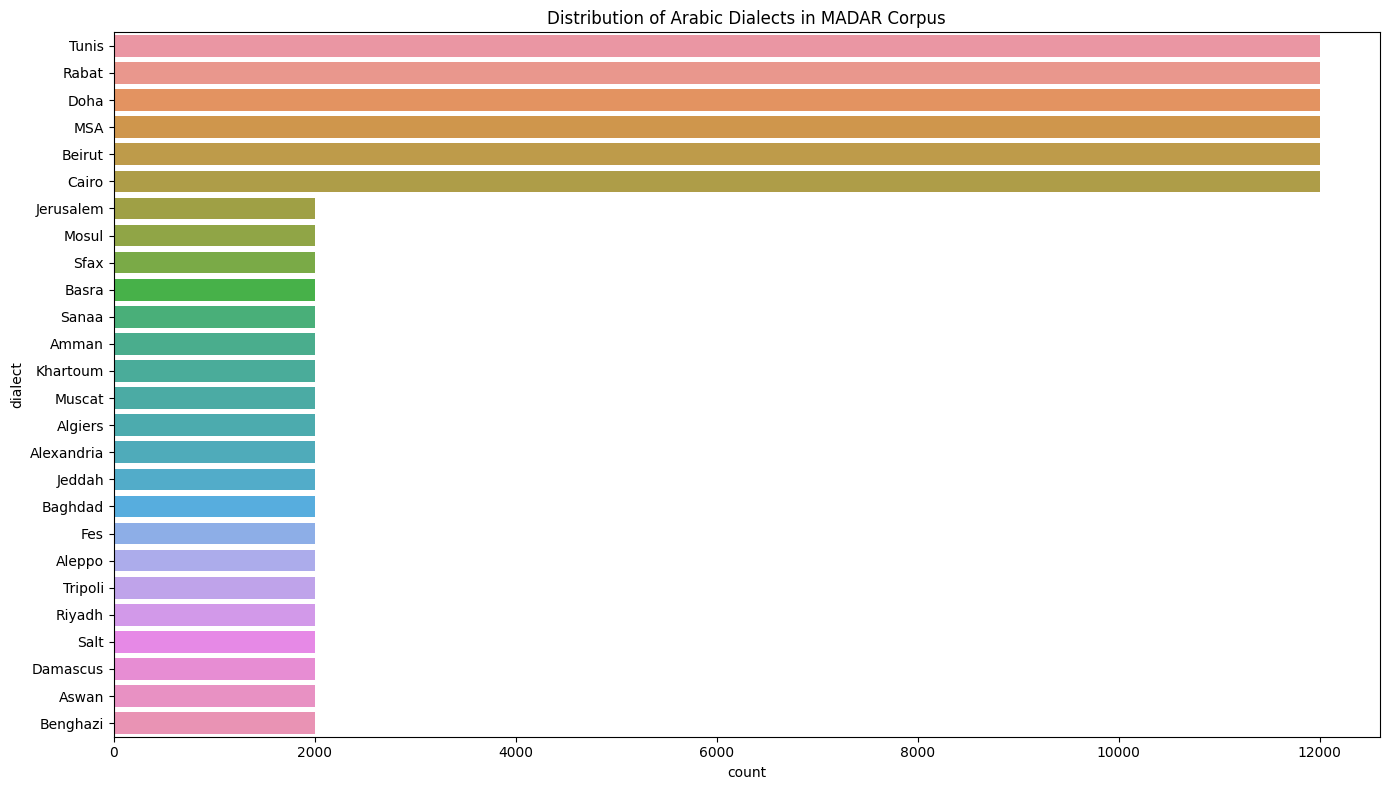

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` inste

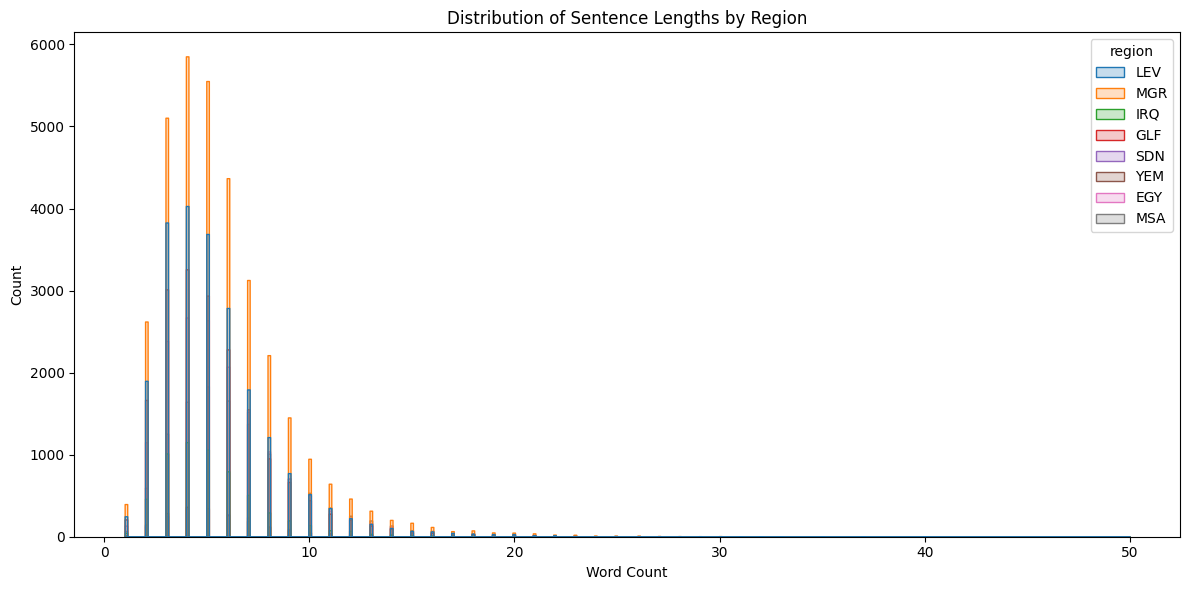

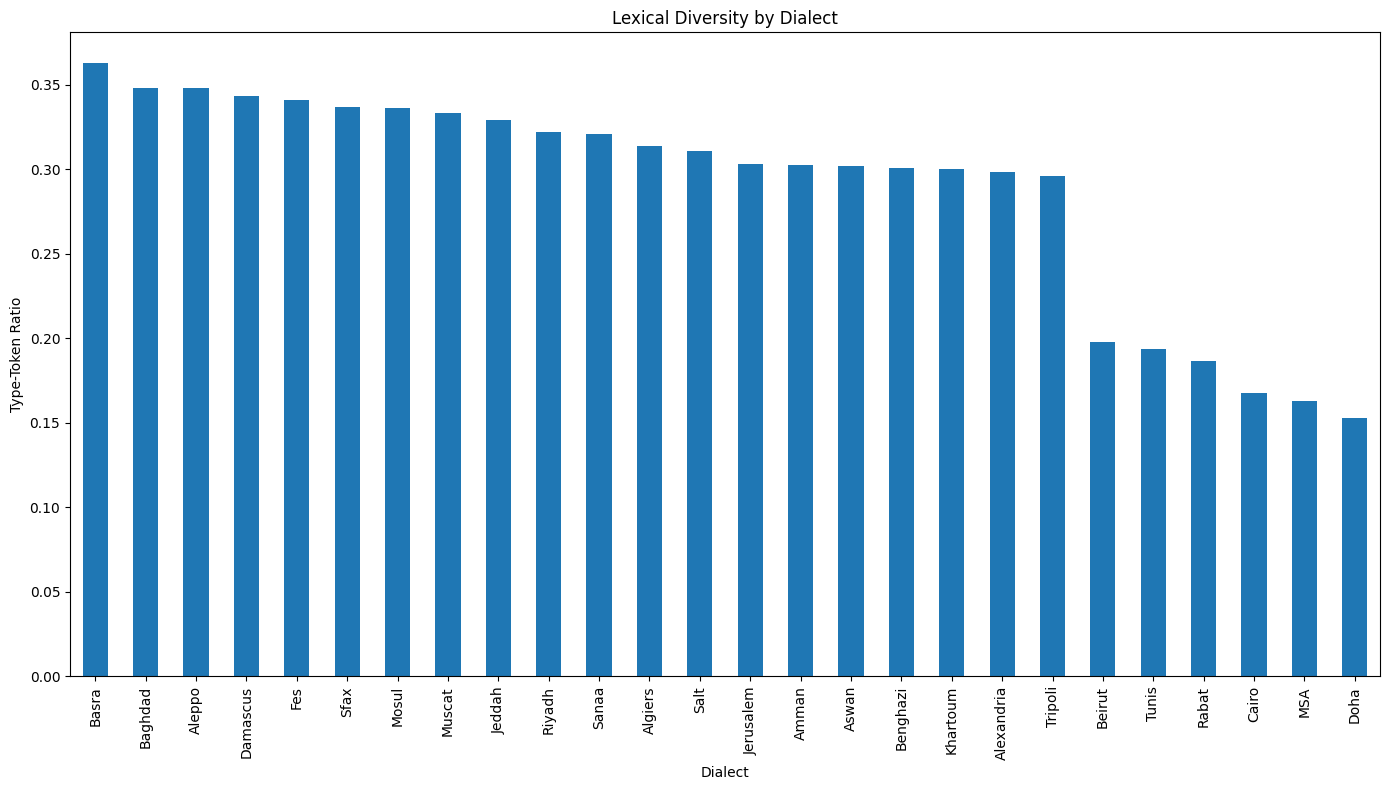

In [5]:
# Path to MADAR corpus
corpus_dir = "/kaggle/input/madar-dataset/MADAR.Parallel-Corpora-Public-Version1.1-25MAR2021/MADAR.Parallel-Corpora-Public-Version1.1-25MAR2021/MADAR_Corpus"
corpus = load_madar_corpus(corpus_dir,preprocessor)

# Display sample data
display(corpus.head())
# Create label encodings
dialects = sorted(corpus['dialect'].unique())
dialect_mapping = {dialect: idx for idx, dialect in enumerate(dialects)}
corpus['label'] = corpus['dialect'].map(dialect_mapping)

# Exploratory Data Analysis
plt.figure(figsize=(14, 8))
sns.countplot(y='dialect', data=corpus, order=corpus['dialect'].value_counts().index)
plt.title('Distribution of Arabic Dialects in MADAR Corpus')
plt.tight_layout()
plt.show()

# Analyze text length
corpus['word_count'] = corpus['text_processed'].apply(lambda x: len(x.split()))
plt.figure(figsize=(12, 6))
sns.histplot(data=corpus, x='word_count', hue='region', element='step', common_norm=False)
plt.title('Distribution of Sentence Lengths by Region')
plt.xlabel('Word Count')
plt.tight_layout()
plt.show()

# Lexical diversity by dialect
def calculate_lexical_diversity(texts):
    tokens = [word for text in texts for word in text.split()]
    return len(set(tokens)) / len(tokens) if tokens else 0

lexical_diversity = corpus.groupby('dialect')['text_processed'].apply(calculate_lexical_diversity).sort_values(ascending=False)

plt.figure(figsize=(14, 8))
lexical_diversity.plot(kind='bar')
plt.title('Lexical Diversity by Dialect')
plt.xlabel('Dialect')
plt.ylabel('Type-Token Ratio')
plt.tight_layout()
plt.show()

In [2]:
# class MadarDialectPreprocessor:
#     """
#     Enhanced Arabic text preprocessor with dialect-aware capabilities
#     based on MADAR lexicon guidelines
#     """
#     def __init__(self):
#         self.arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:\"؟.,'{}~¦+|!\"…\"–ـ'''
#         self.english_punctuations = '''!\"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'''
#         self.punctuations_list = self.arabic_punctuations + self.english_punctuations
        
#         # Character normalization mappings based on CODA guidelines
#         self.char_map = {
#             'إ': 'ا', 'أ': 'ا', 'آ': 'ا',  # Alef variations
#             'ة': 'ه',  # Taa marbuta to Haa
#             'ى': 'ي',  # Alef maksura to Yaa
#             'گ': 'ك',  # Persian Gaf to Kaf
#             'ڤ': 'ف',  # Veh to Feh
#             'پ': 'ب',  # Persian Peh to Beh
#             'چ': 'ج',  # Persian Tcheh to Jeem
#             'ژ': 'ز',  # Persian Jeh to Zain
#         }
        
#         # CAPHI pronunciation map for certain characters (simplified)
#         self.caphi_map = {
#             'ج': {'EGY': 'g', 'LEV': 'j', 'GLF': 'j', 'MSA': 'j'},
#             'ق': {'EGY': '2', 'LEV': '2', 'GLF': 'g', 'MSA': 'q'},
#             'ث': {'EGY': 's', 'LEV': 's', 'GLF': 'th', 'MSA': 'th'},
#             'ذ': {'EGY': 'z', 'LEV': 'z', 'GLF': 'dh', 'MSA': 'dh'}
#         }
        
 
#     def normalize_chars(self, text):
#         """Normalize Arabic characters based on CODA guidelines"""
#         if not text:
#             return ""
        
#         # Apply character mapping
#         for source, target in self.char_map.items():
#             text = text.replace(source, target)
        
#         return text
    
#     def remove_diacritics(self, text):
#         """Remove Arabic diacritics, tatweel and tashkeel"""
#         text = strip_tashkeel(text)
#         text = strip_diacritics(text)
#         text = strip_tatweel(text)
#         return text
    
#     def remove_punctuation(self, text):
#         """Remove punctuation but preserve underscores for certain models"""
#         for char in self.punctuations_list:
#             if char != '_':  # Keep underscore for Twitter models
#                 text = text.replace(char, ' ')
        
#         # Remove extra spaces
#         text = re.sub(r'\s+', ' ', text).strip()
#         return text
    
#     def normalize_dialectal_words(self, text, dialect=None):
#         """Apply dialect-specific word normalization using MADAR lexicon"""
#         if not dialect :
#             return text
            
#         words = text.split()
#         normalized = []
        
#         for word in words:
#                 normalized.append(word)
        
#         return ' '.join(normalized)
    
#     def apply_madar_dialect_features(self, text, dialect=None):
#         """
#         Apply MADAR-specific dialect features based on lexicon insights
#         This implements the enhanced_preprocessing functionality for dialect features
#         """
#         if not dialect:
#             return text
            
#         # Handle dialectal phonological variations based on CAPHI guidelines
#         words = text.split()
#         processed_words = []
        
#         for word in words:
#             # Apply dialect-specific character transformations
#             if dialect == 'EGY' or dialect in ['Cairo', 'Alexandria', 'Aswan']:
#                 # Egyptian dialect: ج → g, ق → '
#                 for char, replacement in self.caphi_map.items():
#                     if char in word and 'EGY' in replacement:
#                         word = word.replace(char, replacement['EGY'])
#             elif dialect == 'LEV' or dialect in ['Beirut', 'Damascus', 'Aleppo']:
#                 # Levantine dialect features
#                 for char, replacement in self.caphi_map.items():
#                     if char in word and 'LEV' in replacement:
#                         word = word.replace(char, replacement['LEV'])
#             elif dialect == 'GLF' or dialect in ['Doha', 'Riyadh', 'Jeddah']:
#                 # Gulf dialect features
#                 for char, replacement in self.caphi_map.items():
#                     if char in word and 'GLF' in replacement:
#                         word = word.replace(char, replacement['GLF'])
                
#             processed_words.append(word)
        
#         # Multi-word expression handling from MADAR
#         # Identify and preserve common dialectal multi-word expressions
#         result = []
#         i = 0
#         while i < len(processed_words):    
#             # If no multi-word match, add the single word
#             result.append(processed_words[i])
#             i += 1
                
#         return ' '.join(result)
    
#     def preprocess(self, text, dialect=None, embedding_model='ARABERT'):
#         """
#         Full preprocessing pipeline with dialect awareness
        
#         Args:
#             text: Input Arabic text
#             dialect: Dialect identifier (e.g., 'EGY', 'LEV', 'GLF')
#             embedding_model: Target model type ('TWITTER', 'WIKI', 'ARABERT')
        
#         Returns:
#             Preprocessed text ready for embedding or classification
#         """
#         if not isinstance(text, str) or not text.strip():
#             return ""
        
#         # Basic cleaning
#         text = self.normalize_chars(text)
#         text = self.remove_diacritics(text)
        
#         # Model-specific preprocessing
#         if embedding_model == 'TWITTER':
#             # Twitter models often use underscores and have specific handling
#             text = text.replace('وو', 'و').replace('يي', 'ي').replace('اا', 'ا')
#             # Skip underscore removal for Twitter models
#         elif embedding_model in ['WIKI', 'FASTTEXT', 'ARABERT']:
#             # Remove underscores for other models
#             text = text.replace('_', '')
        
#         # Remove punctuation
#         text = self.remove_punctuation(text)
        
#         # Apply MADAR-specific dialect features and normalization
#         if dialect:
#             text = self.apply_madar_dialect_features(text, dialect)
#             text = self.normalize_dialectal_words(text, dialect)
        
#         return text

# # Initialize preprocessor
# preprocessor = MadarDialectPreprocessor()

In [3]:
# def extract_madar_features(text, dialect_regions):
#     """Extract MADAR-specific features for improved dialect identification"""
#     features = {}
#     tokens = text.split()
    
#     # 1. Region-specific lexical features
#     for region, cities in dialect_regions.items():
#         # Egyptian dialectal markers
#         if region == 'EGY':
#             features[f'has_egy_features'] = 1 if any(w in ['عايز', 'كده', 'دلوقتي', 'فين'] for w in tokens) else 0
        
#         # Levantine dialectal markers
#         elif region == 'LEV':
#             features[f'has_lev_features'] = 1 if any(w in ['بدي', 'هلق', 'هون', 'شو'] for w in tokens) else 0
        
#         # Gulf dialectal markers
#         elif region == 'GLF':
#             features[f'has_glf_features'] = 1 if any(w in ['ابغى', 'وش', 'يبه', 'تو'] for w in tokens) else 0
        
#         # Maghrebi dialectal markers
#         elif region == 'MGR':
#             features[f'has_mgr_features'] = 1 if any(w in ['غادي', 'بزاف', 'واخا', 'شنو'] for w in tokens) else 0
    
#     # 2. Phonological features (CAPHI-based)
#     features['has_egy_g'] = 1 if 'g' in text else 0  # Egyptian ج pronunciation
#     features['has_glf_g'] = 1 if 'g' in text else 0  # Gulf ق pronunciation
#     features['has_levantine_glottal'] = 1 if any("'" in w for w in tokens) else 0
    
#     # 3. Morphological features
#     features['has_b_prefix'] = 1 if any(w.startswith('ب') for w in tokens) else 0
#     features['has_h_prefix'] = 1 if any(w.startswith('ح') for w in tokens) else 0
#     features['has_k_prefix'] = 1 if any(w.startswith('ك') for w in tokens) else 0
    
#     return features

Loading MADAR corpus files...


  0%|          | 0/26 [00:00<?, ?it/s]

Loaded 112000 samples across 26 dialects

Samples per dialect:
  Jerusalem: 2000 samples
  Tunis: 12000 samples
  Mosul: 2000 samples
  Sfax: 2000 samples
  Rabat: 12000 samples
  Basra: 2000 samples
  Muscat: 2000 samples
  Khartoum: 2000 samples
  Amman: 2000 samples
  Sanaa: 2000 samples
  Baghdad: 2000 samples
  Jeddah: 2000 samples
  Cairo: 12000 samples
  Algiers: 2000 samples
  Alexandria: 2000 samples
  Aleppo: 2000 samples
  Fes: 2000 samples
  Beirut: 12000 samples
  Tripoli: 2000 samples
  Doha: 12000 samples
  MSA: 12000 samples
  Riyadh: 2000 samples
  Salt: 2000 samples
  Damascus: 2000 samples
  Aswan: 2000 samples
  Benghazi: 2000 samples


,sentID.BTEC,split,lang,sent,dialect,region
0,5,corpus-6-test-corpus-26-train,JER,هناك، قدام مكتب استعلامات السياح بالزبط.,Jerusalem,LEV
1,9,corpus-6-test-corpus-26-train,JER,عمري ما سمعت هدا العنوان هون.,Jerusalem,LEV
2,11,corpus-6-test-corpus-26-train,JER,خليك ماشي دغري لتلاقي صيدلية.,Jerusalem,LEV
3,26,corpus-6-test-corpus-26-train,JER,قديش الفطور؟,Jerusalem,LEV
4,27,corpus-6-test-corpus-26-train,JER,كيف بقدر أساعدك؟,Jerusalem,LEV


Preprocessing corpus texts...


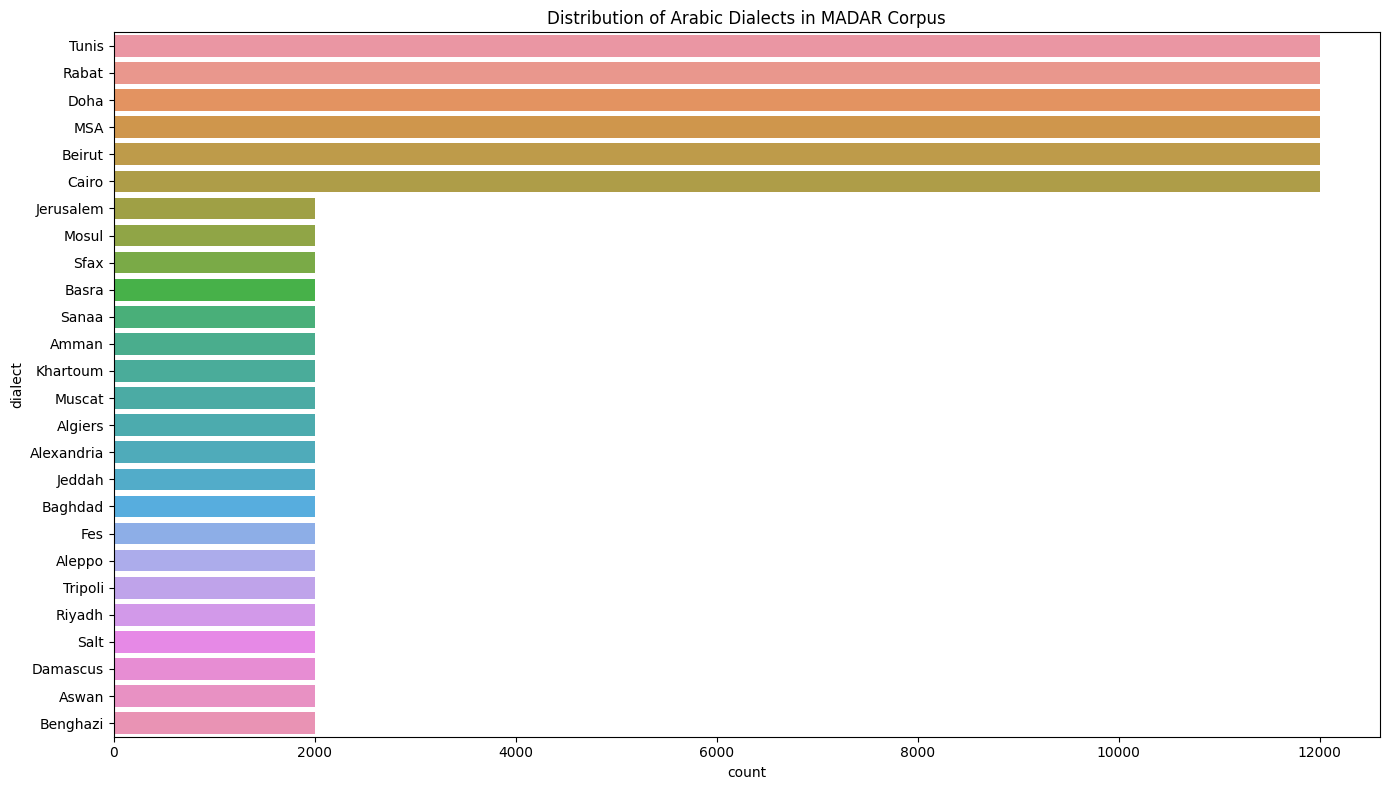

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` inste

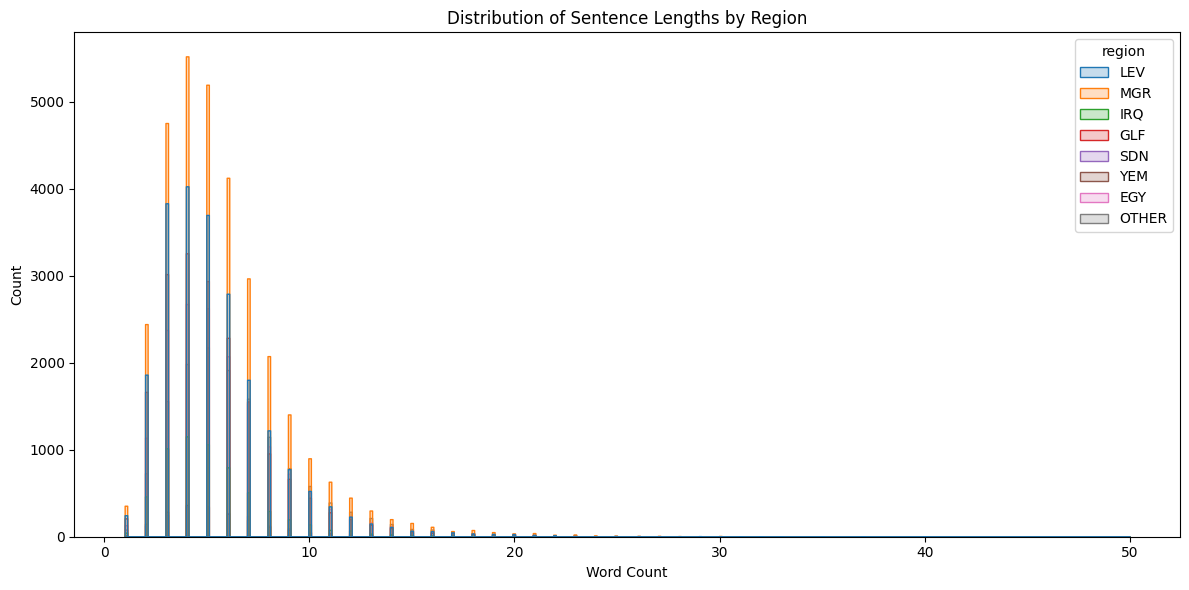

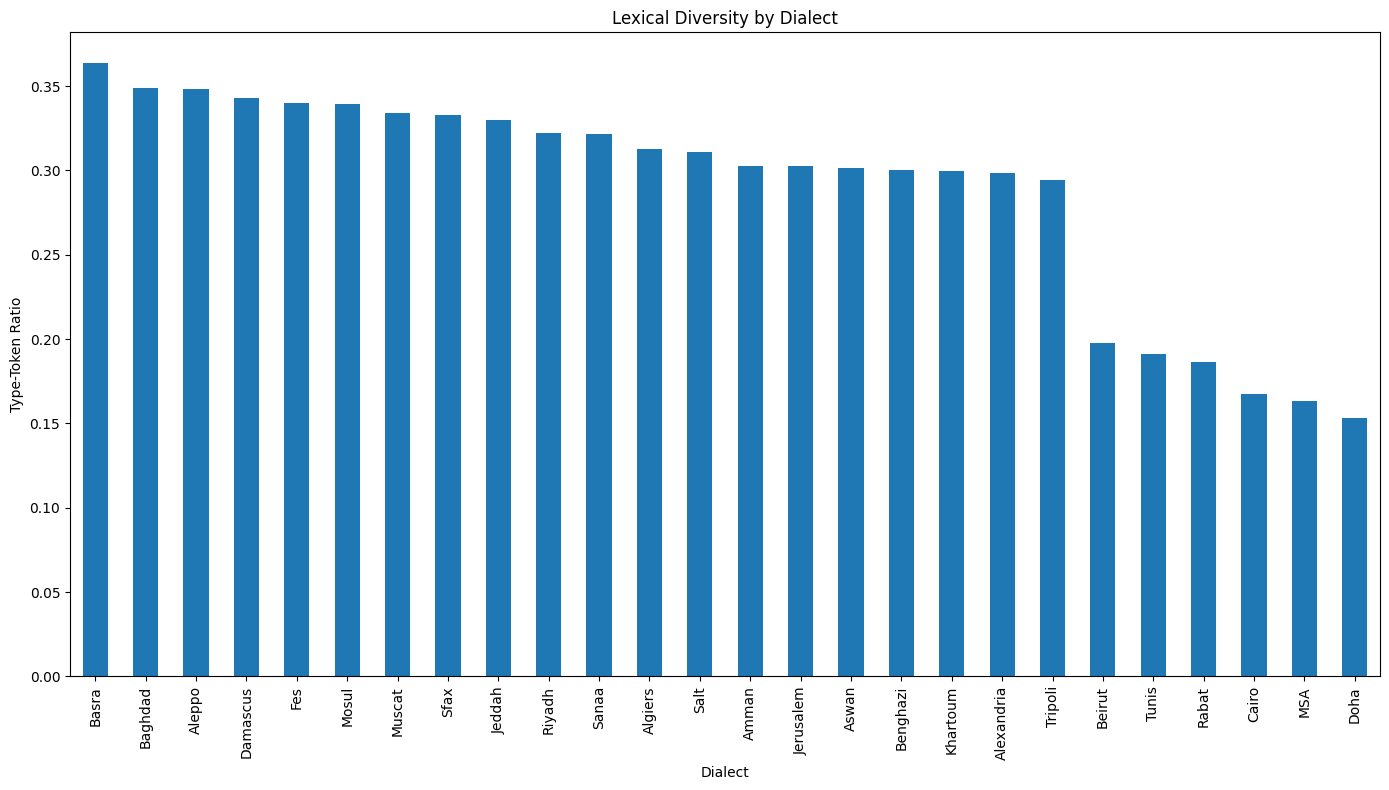

In [19]:
# def load_madar_corpus(corpus_dir):
#     """
#     Load all dialect files from the MADAR corpus directory with enhanced
#     data quality checks and preprocessing
#     """
#     print("Loading MADAR corpus files...")
    
#     # Find all TSV files (exclude index files)
#     dialect_files = [f for f in os.listdir(corpus_dir) 
#                      if f.startswith("MADAR.corpus.") and not f.endswith("index.tsv")]
    
#     all_data = []
#     dialects_info = {}
    
#     for file in tqdm(dialect_files):
#         # Extract dialect name from filename
#         dialect = file.replace("MADAR.corpus.", "").replace(".tsv", "")
        
#         file_path = os.path.join(corpus_dir, file)
#         df = pd.read_csv(file_path, sep='\t')
        
#         # Add dialect column if not already present
#         if 'dialect' not in df.columns:
#             df['dialect'] = dialect
        
#         # Track dialect information
#         dialects_info[dialect] = len(df)
        
#         all_data.append(df)
    
#     # Combine all data
#     corpus = pd.concat(all_data, ignore_index=True)
    
#     # Create dialect region mapping
#     dialect_regions = {
#         'EGY': ['Cairo', 'Alexandria', 'Aswan'],
#         'LEV': ['Beirut', 'Damascus', 'Aleppo', 'Jerusalem', 'Amman', 'Salt'],
#         'GLF': ['Doha', 'Riyadh', 'Jeddah', 'Muscat'],
#         'MGR': ['Rabat', 'Fes', 'Tripoli', 'Tunis', 'Sfax', 'Algiers'],
#         'IRQ': ['Baghdad', 'Basra', 'Mosul'],
#         'SDN': ['Khartoum'],
#         'YEM': ['Sanaa']
#     }
    
#     # Add region information
#     corpus['region'] = corpus['dialect'].apply(
#         lambda d: next((region for region, cities in dialect_regions.items() 
#                         if d in cities), 'OTHER')
#     )
    
#     # Basic statistics
#     print(f"Loaded {len(corpus)} samples across {corpus['dialect'].nunique()} dialects")
#     print("\nSamples per dialect:")
#     for dialect, count in dialects_info.items():
#         print(f"  {dialect}: {count} samples")
    
#     return corpus

# # Path to MADAR corpus
# corpus_dir = "/kaggle/input/madar-dataset/MADAR.Parallel-Corpora-Public-Version1.1-25MAR2021/MADAR.Parallel-Corpora-Public-Version1.1-25MAR2021/MADAR_Corpus"
# corpus = load_madar_corpus(corpus_dir)

# # Display sample data
# display(corpus.head())

# # Apply preprocessing to corpus with dialect awareness
# print("Preprocessing corpus texts...")
# corpus['text_processed'] = corpus.apply(
#     lambda row: preprocessor.preprocess(
#         row['sent'], 
#         dialect=row['region'],  # Use region for broader dialect groups
#         embedding_model='ARABERT'  # Default to ARABERT preprocessing
#     ), 
#     axis=1
# )

# # Create label encodings
# dialects = sorted(corpus['dialect'].unique())
# dialect_mapping = {dialect: idx for idx, dialect in enumerate(dialects)}
# corpus['label'] = corpus['dialect'].map(dialect_mapping)

# # Exploratory Data Analysis
# plt.figure(figsize=(14, 8))
# sns.countplot(y='dialect', data=corpus, order=corpus['dialect'].value_counts().index)
# plt.title('Distribution of Arabic Dialects in MADAR Corpus')
# plt.tight_layout()
# plt.show()

# # Analyze text length
# corpus['word_count'] = corpus['text_processed'].apply(lambda x: len(x.split()))
# plt.figure(figsize=(12, 6))
# sns.histplot(data=corpus, x='word_count', hue='region', element='step', common_norm=False)
# plt.title('Distribution of Sentence Lengths by Region')
# plt.xlabel('Word Count')
# plt.tight_layout()
# plt.show()

# # Lexical diversity by dialect
# def calculate_lexical_diversity(texts):
#     tokens = [word for text in texts for word in text.split()]
#     return len(set(tokens)) / len(tokens) if tokens else 0

# lexical_diversity = corpus.groupby('dialect')['text_processed'].apply(calculate_lexical_diversity).sort_values(ascending=False)

# plt.figure(figsize=(14, 8))
# lexical_diversity.plot(kind='bar')
# plt.title('Lexical Diversity by Dialect')
# plt.xlabel('Dialect')
# plt.ylabel('Type-Token Ratio')
# plt.tight_layout()
# plt.show()

In [6]:
def prepare_splits(corpus):
    """
    Prepare train/val/test splits using official MADAR splits where available,
    with stratification by dialect to ensure balanced representation
    """
    # Extract official splits if present
    train_data = corpus[corpus['split'].str.contains('train', na=False)]
    test_data = corpus[corpus['split'].str.contains('test', na=False)]
    dev_data = corpus[corpus['split'].str.contains('dev', na=False)]

    X_train = train_data['text_processed']
    y_train = train_data['label']
    dialect_train = train_data['dialect']
    
    X_val = dev_data['text_processed'] 
    y_val = dev_data['label']
    dialect_val = dev_data['dialect']
    
    X_test = test_data['text_processed']
    y_test = test_data['label']
    dialect_test = test_data['dialect']
  
    # Verify class distribution
    train_dist = Counter(dialect_train)
    val_dist = Counter(dialect_val)
    test_dist = Counter(dialect_test)
    
    print(f"Training set: {len(X_train)} samples")
    print(f"Validation set: {len(X_val)} samples")
    print(f"Test set: {len(X_test)} samples")
    
    # Calculate and print distribution similarity using Jensen-Shannon distance
    from scipy.spatial.distance import jensenshannon
    
    # Normalize distributions
    train_vec = np.array([train_dist[d] for d in dialects]) / sum(train_dist.values())
    val_vec = np.array([val_dist[d] for d in dialects]) / sum(val_dist.values())
    test_vec = np.array([test_dist[d] for d in dialects]) / sum(test_dist.values())
    
    js_train_val = jensenshannon(train_vec, val_vec)
    js_train_test = jensenshannon(train_vec, test_vec)
    
    print(f"Distribution similarity (Jensen-Shannon distance):")
    print(f"  Train-Val: {js_train_val:.4f} ")
    print(f"  Train-Test: {js_train_test:.4f} ")
    
    return X_train, y_train, X_val, y_val, X_test, y_test, dialect_train, dialect_val, dialect_test

# Split the data
X_train, y_train, X_val, y_val, X_test, y_test, dialect_train, dialect_val, dialect_test = prepare_splits(corpus)

Training set: 95600 samples
Validation set: 11200 samples
Test set: 52000 samples
Distribution similarity (Jensen-Shannon distance):
  Train-Val: 0.0167 
  Train-Test: 0.3145 


In [8]:
class MadarWordEmbeddings:
    """
    Manager for multiple Arabic word embedding models with unified interface
    and OOV handling strategies
    """
    def __init__(self):
        self.models = {}
        self.embedding_dim = {}
        self.vocab = {}
        self.custom_word2vec = None
        
    def load_aravec_wiki(self, path="/kaggle/working/full_grams_cbow_300_wiki.mdl"):
        """Load AraVec Wiki embeddings"""
        print(f"Loading AraVec Wiki embeddings from {path}")
        try:
            model = Word2Vec.load(path).wv
            self.models['WIKI'] = model
            self.embedding_dim['WIKI'] = model.vector_size
            self.vocab['WIKI'] = set(model.index_to_key)
            print(f"Loaded AraVec Wiki model with {len(model.index_to_key):,} words and {model.vector_size} dimensions")
            return True
        except Exception as e:
            print(f"Failed to load AraVec Wiki embeddings: {e}")
            return False
    
    def load_aravec_twitter(self, path="/kaggle/working/full_grams_cbow_300_twitter.mdl"):
        """Load AraVec Twitter embeddings"""
        print(f"Loading AraVec Twitter embeddings from {path}")
        try:
            model = Word2Vec.load(path).wv
            self.models['TWITTER'] = model
            self.embedding_dim['TWITTER'] = model.vector_size
            self.vocab['TWITTER'] = set(model.index_to_key)
            print(f"Loaded AraVec Twitter model with {len(model.index_to_key):,} words and {model.vector_size} dimensions")
            return True
        except Exception as e:
            print(f"Failed to load AraVec Twitter embeddings: {e}")
            return False
    
    def load_fasttext(self, path="/kaggle/working/cc.ar.300.vec"):
        """Load FastText Arabic embeddings"""
        print(f"Loading FastText embeddings from {path}")
        try:
            model = KeyedVectors.load_word2vec_format(path)
            self.models['FASTTEXT'] = model
            self.embedding_dim['FASTTEXT'] = model.vector_size
            self.vocab['FASTTEXT'] = set(model.index_to_key)
            print(f"Loaded FastText model with {len(model.index_to_key):,} words and {model.vector_size} dimensions")
            return True
        except Exception as e:
            print(f"Failed to load FastText embeddings: {e}")
            return False
    
    def train_custom_word2vec(self, texts, embedding_dim=300, min_count=3, workers=4):
        """Train a custom Word2Vec model on the provided texts"""
        print("Tokenizing texts for custom Word2Vec...")
        tokenized_texts = [text.split() for text in tqdm(texts)]
        text_lengths = [len(t) for t in tokenized_texts]  

        print(f"Training custom Word2Vec model (dim={embedding_dim})...")
        model = Word2Vec(
            sentences=tokenized_texts,
            vector_size=embedding_dim,
            window=int(np.quantile(text_lengths, 0.9)),
            min_count=min_count,
            workers=workers,
            sg=0  # CBOW model
        )
        
        self.custom_word2vec = model.wv
        self.models['CUSTOM'] = model.wv
        self.embedding_dim['CUSTOM'] = embedding_dim
        self.vocab['CUSTOM'] = set(model.wv.index_to_key)
        
        print(f"Trained custom Word2Vec model with {len(model.wv.index_to_key):,} words")
        return model.wv
    
    def get_embedding_matrix(self, word_to_idx, model_name='CUSTOM', oov_strategy='random'):
        """
        Create an embedding matrix for nn.Embedding from the specified model
        
        Args:
            word_to_idx: Dictionary mapping words to indices
            model_name: Which embedding model to use
            oov_strategy: How to handle OOV words ('random', 'zeros', 'average')
        
        Returns:
            Embedding matrix of shape (vocab_size, embedding_dim)
        """
        if model_name not in self.models:
            raise ValueError(f"Model {model_name} not loaded")
        
        model = self.models[model_name]
        embedding_dim = self.embedding_dim[model_name]
        vocab_size = len(word_to_idx)
        
        # Initialize embedding matrix
        embedding_matrix = np.zeros((vocab_size, embedding_dim))
        
        # Track OOV statistics
        oov_count = 0
        total_count = 0
        
        for word, idx in word_to_idx.items():
            if idx != 0:  # Skip padding token
                total_count += 1
                if word in model:
                    embedding_matrix[idx] = model[word]
                else:
                    oov_count += 1
                    # Handle OOV based on strategy
                    if oov_strategy == 'random':
                        embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)
                    elif oov_strategy == 'zeros':
                        # Already zeros from initialization
                        pass
                    elif oov_strategy == 'average':
                        # Try other models
                        vectors = []
                        for other_model_name, other_model in self.models.items():
                            if other_model_name != model_name and word in other_model:
                                vectors.append(other_model[word])
                        
                        if vectors:
                            embedding_matrix[idx] = np.mean(vectors, axis=0)
                        else:
                            embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)
        
        print(f"Embedding matrix created with shape {embedding_matrix.shape}")
        print(f"OOV words: {oov_count}/{total_count} ({oov_count/total_count*100:.2f}%)")
        
        return embedding_matrix
    
    def get_closest_words(self, word, model_name='CUSTOM', topn=10):
        """Find most similar words for OOV handling"""
        if model_name not in self.models:
            raise ValueError(f"Model {model_name} not loaded")
        
        model = self.models[model_name]
        
        if word in model:
            return model.most_similar(word, topn=topn)
        else:
            # Try character n-gram similarity to find closest match
            vocab = list(model.index_to_key)
            
            # Simple Levenshtein distance for demo
            def levenshtein(s1, s2):
                if len(s1) < len(s2):
                    return levenshtein(s2, s1)
                if len(s2) == 0:
                    return len(s1)
                
                previous_row = range(len(s2) + 1)
                for i, c1 in enumerate(s1):
                    current_row = [i + 1]
                    for j, c2 in enumerate(s2):
                        insertions = previous_row[j + 1] + 1
                        deletions = current_row[j] + 1
                        substitutions = previous_row[j] + (c1 != c2)
                        current_row.append(min(insertions, deletions, substitutions))
                    previous_row = current_row
                
                return previous_row[-1]
            
            # Find closest words by edit distance (simplified for demo)
            distances = [(w, levenshtein(word, w)) for w in vocab[:5000]]  # Limit search for speed
            closest = sorted(distances, key=lambda x: x[1])[:topn]
            
            # Get embeddings for these words
            return [(w, 1.0 - d/max(len(word), len(w))) for w, d in closest]
    
    def build_vocab(self, texts, min_count=1):
        """Build vocabulary from texts"""
        print("Building vocabulary from texts...")
        word_counts = Counter()
        
        for text in texts:
            words = text.split()
            word_counts.update(words)
        
        # Filter by min_count
        vocab = [word for word, count in word_counts.items() if count >= min_count]
        
        # Create word->index mapping
        word_to_idx = {word: idx + 1 for idx, word in enumerate(vocab)}
        word_to_idx['<PAD>'] = 0  # Add padding token
        
        print(f"Built vocabulary with {len(word_to_idx):,} unique words")
        return word_to_idx

# Initialize word embeddings manager
arabic_embeddings = MadarWordEmbeddings()

# Load pre-trained embedding models
arabic_embeddings.load_aravec_wiki() 
arabic_embeddings.load_aravec_twitter()  
arabic_embeddings.load_fasttext()  

# Train custom Word2Vec on our corpus
arabic_embeddings.train_custom_word2vec(X_train)

# Build vocabulary
word_to_idx = arabic_embeddings.build_vocab(X_train)

# Create embedding matrices for different models
embedding_matrices = {
    'CUSTOM': arabic_embeddings.get_embedding_matrix(word_to_idx, 'CUSTOM', oov_strategy='random'),
    'WIKI': arabic_embeddings.get_embedding_matrix(word_to_idx, 'WIKI', oov_strategy='average') if 'WIKI' in arabic_embeddings.models else None,
    'TWITTER': arabic_embeddings.get_embedding_matrix(word_to_idx, 'TWITTER', oov_strategy='average') if 'TWITTER' in arabic_embeddings.models else None,
    'FASTTEXT': arabic_embeddings.get_embedding_matrix(word_to_idx, 'FASTTEXT', oov_strategy='average') if 'FASTTEXT' in arabic_embeddings.models else None,
}

# Filter out any None matrices
embedding_matrices = {k: v for k, v in embedding_matrices.items() if v is not None}

# Examine vocabulary overlap between models
def calculate_vocab_overlap():
    """Calculate vocabulary overlap between different embedding models"""
    if len(arabic_embeddings.vocab) <= 1:
        print("Need at least two embedding models to calculate overlap")
        return
    
    overlap_data = []
    
    # Get all model pairs
    model_names = list(arabic_embeddings.vocab.keys())
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            model1 = model_names[i]
            model2 = model_names[j]
            
            vocab1 = arabic_embeddings.vocab[model1]
            vocab2 = arabic_embeddings.vocab[model2]
            
            # Calculate overlap
            overlap = len(vocab1 & vocab2)
            overlap_pct1 = overlap / len(vocab1) * 100
            overlap_pct2 = overlap / len(vocab2) * 100
            
            overlap_data.append({
                'Model1': f"{model1} ({len(vocab1):,})",
                'Model2': f"{model2} ({len(vocab2):,})",
                'Overlap': f"{overlap:,} words",
                f'% of {model1}': f"{overlap_pct1:.2f}%",
                f'% of {model2}': f"{overlap_pct2:.2f}%"
            })
    
    # Convert to DataFrame for display
    overlap_df = pd.DataFrame(overlap_data)
    display(overlap_df)
    
    return overlap_df

# Calculate vocabulary overlap
calculate_vocab_overlap()

Loading AraVec Wiki embeddings from /kaggle/working/full_grams_cbow_300_wiki.mdl
Loaded AraVec Wiki model with 662,109 words and 300 dimensions
Loading AraVec Twitter embeddings from /kaggle/working/full_grams_cbow_300_twitter.mdl
Loaded AraVec Twitter model with 1,476,715 words and 300 dimensions
Loading FastText embeddings from /kaggle/working/cc.ar.300.vec
Loaded FastText model with 2,000,000 words and 300 dimensions
Tokenizing texts for custom Word2Vec...


  0%|          | 0/95600 [00:00<?, ?it/s]

Training custom Word2Vec model (dim=300)...
Trained custom Word2Vec model with 19,015 words
Building vocabulary from texts...
Built vocabulary with 58,317 unique words
Embedding matrix created with shape (58317, 300)
OOV words: 39301/58316 (67.39%)
Embedding matrix created with shape (58317, 300)
OOV words: 39778/58316 (68.21%)
Embedding matrix created with shape (58317, 300)
OOV words: 32865/58316 (56.36%)
Embedding matrix created with shape (58317, 300)
OOV words: 34139/58316 (58.54%)


,Model1,Model2,Overlap,% of WIKI,% of TWITTER,% of FASTTEXT,% of CUSTOM
0,"WIKI (662,109)","TWITTER (1,476,715)","235,285 words",35.54%,15.93%,NaN,NaN
1,"WIKI (662,109)","FASTTEXT (2,000,000)","261,531 words",39.50%,NaN,13.08%,NaN
2,"WIKI (662,109)","CUSTOM (19,015)","8,364 words",1.26%,NaN,NaN,43.99%
3,"TWITTER (1,476,715)","FASTTEXT (2,000,000)","459,939 words",NaN,31.15%,23.00%,NaN
4,"TWITTER (1,476,715)","CUSTOM (19,015)","10,360 words",NaN,0.70%,NaN,54.48%
5,"FASTTEXT (2,000,000)","CUSTOM (19,015)","10,035 words",NaN,NaN,0.50%,52.77%


,Model1,Model2,Overlap,% of WIKI,% of TWITTER,% of FASTTEXT,% of CUSTOM
0,"WIKI (662,109)","TWITTER (1,476,715)","235,285 words",35.54%,15.93%,NaN,NaN
1,"WIKI (662,109)","FASTTEXT (2,000,000)","261,531 words",39.50%,NaN,13.08%,NaN
2,"WIKI (662,109)","CUSTOM (19,015)","8,364 words",1.26%,NaN,NaN,43.99%
3,"TWITTER (1,476,715)","FASTTEXT (2,000,000)","459,939 words",NaN,31.15%,23.00%,NaN
4,"TWITTER (1,476,715)","CUSTOM (19,015)","10,360 words",NaN,0.70%,NaN,54.48%
5,"FASTTEXT (2,000,000)","CUSTOM (19,015)","10,035 words",NaN,NaN,0.50%,52.77%


In [18]:
class ArabicTransformers:
    """
    Manager for Arabic pre-trained transformer models
    """
    def __init__(self):
        self.model_names = [
            'UBC-NLP/MARBERT',  # Multi-dialect BERT
            'aubmindlab/bert-base-arabertv02',  # MSA BERT
            'CAMeL-Lab/bert-base-arabic-camelbert-ca',  # Classical Arabic BERT
            'asafaya/bert-base-arabic',  # Arabic BERT
            'kuisailab/albert-ar-small-twitter'  # Arabic Twitter ALBERT
        ]
        self.tokenizers = {}
        self.models = {}
        
    def load_model(self, model_name, num_labels=None):
        """Load a pre-trained transformer model and tokenizer"""
        if model_name not in self.model_names:
            print(f"Warning: {model_name} is not a recognized Arabic transformer model")
        
        print(f"Loading transformer model: {model_name}")
        try:
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            
            if num_labels is not None:
                model = AutoModelForSequenceClassification.from_pretrained(
                    model_name,
                    num_labels=num_labels,
                    output_attentions=True
                )
            else:
                model = AutoModel.from_pretrained(model_name)
            
            self.tokenizers[model_name] = tokenizer
            self.models[model_name] = model
            
            print(f"Successfully loaded {model_name}")
            return tokenizer, model
        except Exception as e:
            print(f"Failed to load {model_name}: {e}")
            return None, None
    
    def list_available_models(self):
        """List available Arabic transformer models"""
        return self.model_names
    
    def get_model_size(self, model_name):
        """Get model size in millions of parameters"""
        if model_name not in self.models:
            print(f"Model {model_name} not loaded")
            return None
        
        model = self.models[model_name]
        return sum(p.numel() for p in model.parameters()) / 1e6

# Initialize transformers manager
arabic_transformers = ArabicTransformers()

# Display available models
print("Available Arabic transformer models:")
for model_name in arabic_transformers.list_available_models():
    print(f"  - {model_name}")
# Load MARBERT for dialect classification
# num_labels = len(dialect_mapping)
num_labels=len(corpus['label'].unique())
marbert_tokenizer = AutoTokenizer.from_pretrained('UBC-NLP/MARBERT')
marbert_model = AutoModelForSequenceClassification.from_pretrained(
    'UBC-NLP/MARBERT',
    num_labels=num_labels,
    attn_implementation="eager"  # Force manual attention
)
# Load AraBERT for embeddings
arabert_tokenizer = AutoTokenizer.from_pretrained('aubmindlab/bert-base-arabertv02')
arabert_model = AutoModelForSequenceClassification.from_pretrained(
    'aubmindlab/bert-base-arabertv02',
    num_labels=num_labels
)

Available Arabic transformer models:
  - UBC-NLP/MARBERT
  - aubmindlab/bert-base-arabertv02
  - CAMeL-Lab/bert-base-arabic-camelbert-ca
  - asafaya/bert-base-arabic
  - kuisailab/albert-ar-small-twitter


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [30]:
class DialectDataset(Dataset):
    """Dataset for non-contextual word embeddings"""
    def __init__(self, texts, labels, word_to_idx, max_len=50):
        self.texts = texts
        self.labels = labels
        self.word_to_idx = word_to_idx
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def text_to_sequence(self, text):
        """Convert text to sequence of word indices"""
        words = text.split()
        seq = [self.word_to_idx.get(word, 0) for word in words[:self.max_len]]
        
        # Pad sequence
        if len(seq) < self.max_len:
            seq = seq + [0] * (self.max_len - len(seq))
            
        return seq
    
    def __getitem__(self, idx):
        text = self.texts.iloc[idx]
        label = self.labels.iloc[idx]
        
        seq = self.text_to_sequence(text)
        return torch.LongTensor(seq), torch.tensor(label, dtype=torch.long)

class TransformerDialectDataset(Dataset):
    """Dataset for transformer models"""
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts.iloc[idx]
        label = self.labels.iloc[idx]
        
        # Tokenize for transformer model
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Analyze text lengths to determine max_len
text_lengths = X_train.apply(lambda x: len(x.split()))
seq_max_len = int(text_lengths.quantile(0.95))  # 95th percentile
print(f"Using sequence max length: {seq_max_len}")

# Create datasets for word embedding model
train_dataset = DialectDataset(X_train, y_train, word_to_idx, seq_max_len)
val_dataset = DialectDataset(X_val, y_val, word_to_idx, seq_max_len)
test_dataset = DialectDataset(X_test, y_test, word_to_idx, seq_max_len)

# Create datasets for transformer model
if marbert_tokenizer is not None:
    transformer_max_len = 128
    train_transformer_dataset = TransformerDialectDataset(X_train, y_train, marbert_tokenizer, transformer_max_len)
    val_transformer_dataset = TransformerDialectDataset(X_val, y_val, marbert_tokenizer, transformer_max_len)
    test_transformer_dataset = TransformerDialectDataset(X_test, y_test, marbert_tokenizer, transformer_max_len)

# Create dataloaders
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

transformer_batch_size = 96
if marbert_tokenizer is not None:
    train_transformer_loader = DataLoader(train_transformer_dataset, batch_size=transformer_batch_size, shuffle=True)
    val_transformer_loader = DataLoader(val_transformer_dataset, batch_size=transformer_batch_size)
    test_transformer_loader = DataLoader(test_transformer_dataset, batch_size=transformer_batch_size)

Using sequence max length: 11


In [11]:
class MADARFeatureLayer(nn.Module):
    """Special layer to incorporate MADAR-specific dialect features"""
    def __init__(self, input_dim, lexicon_feature_dim=10):
        super().__init__()
        
        # Learnable parameters for dialect-specific patterns
        self.region_embeddings = nn.Embedding(7, lexicon_feature_dim)  # 7 major dialect regions
        self.concept_weights = nn.Parameter(torch.randn(lexicon_feature_dim, input_dim))
        self.attention = nn.Linear(input_dim, 1)
        
    def forward(self, x, region_ids=None):
        """Apply MADAR-specific attention based on lexical patterns"""
        batch_size, seq_len, hidden_dim = x.shape
        
        # Apply attention to focus on dialectal features
        attention_scores = self.attention(x).squeeze(-1)  # [batch_size, seq_len]
        attention_weights = F.softmax(attention_scores, dim=1).unsqueeze(1)  # [batch_size, 1, seq_len]
        
        # Apply region-specific bias if available
        if region_ids is not None:
            region_embed = self.region_embeddings(region_ids)  # [batch_size, lexicon_feature_dim]
            dialect_bias = torch.matmul(region_embed, self.concept_weights)  # [batch_size, hidden_dim]
            dialect_bias = dialect_bias.unsqueeze(1).expand(-1, seq_len, -1)  # [batch_size, seq_len, hidden_dim]
            x = x + dialect_bias * 0.1  # Small bias toward dialectal features
            
        # Weighted sum
        context_vector = torch.matmul(attention_weights, x).squeeze(1)  # [batch_size, hidden_dim]
        
        return context_vector

class MADARFeatureLayer(nn.Module):
    """Enhanced layer to incorporate MADAR-specific dialect features"""
    def __init__(self, input_dim, lexicon_feature_dim=32):
        super().__init__()
        
        # Expanded dimensions for more expressive dialect features
        self.region_embeddings = nn.Embedding(7, lexicon_feature_dim)  # 7 major dialect regions
        
        # Separate weights for different feature types
        self.phonological_weights = nn.Parameter(torch.randn(lexicon_feature_dim, input_dim // 3))
        self.lexical_weights = nn.Parameter(torch.randn(lexicon_feature_dim, input_dim // 3))
        self.morphological_weights = nn.Parameter(torch.randn(lexicon_feature_dim, input_dim // 3))
        
        # More sophisticated attention mechanism
        self.query = nn.Linear(input_dim, input_dim)
        self.key = nn.Linear(input_dim, input_dim)
        self.value = nn.Linear(input_dim, input_dim)
        
        # Feature transformation layers
        self.feature_transform = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.LayerNorm(input_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Output layer normalization for stable training
        self.layer_norm = nn.LayerNorm(input_dim)
        
        # Region-specific gates to control feature integration
        self.region_gates = nn.Parameter(torch.ones(7, 3) * 0.5)  # 7 regions, 3 feature types
        
    def forward(self, x, region_ids=None):
        """Apply MADAR-specific attention based on lexical patterns"""
        batch_size, seq_len, hidden_dim = x.shape
        
        # Self-attention mechanism
        queries = self.query(x)
        keys = self.key(x)
        values = self.value(x)
        
        # Scaled dot-product attention
        attention_scores = torch.matmul(queries, keys.transpose(-2, -1)) / (hidden_dim ** 0.5)
        attention_weights = F.softmax(attention_scores, dim=-1)
        attended_values = torch.matmul(attention_weights, values)
        
        # If region information is available, apply dialect-specific biases
        if region_ids is not None:
            region_embed = self.region_embeddings(region_ids)  # [batch_size, lexicon_feature_dim]
            
            # Split input for specialized feature processing
            x_chunks = torch.chunk(x, 3, dim=2)
            dialect_features = []
            
            # Process each feature type separately with region-specific weights
            for i, (chunk, weights) in enumerate(zip(x_chunks, 
                                                    [self.phonological_weights, 
                                                     self.lexical_weights, 
                                                     self.morphological_weights])):
                # Calculate feature bias
                feature_bias = torch.matmul(region_embed, weights)  # [batch_size, hidden_dim//3]
                
                # Apply region-specific gating to control feature impact
                gates = F.sigmoid(self.region_gates[region_ids, i]).unsqueeze(-1)
                
                # Expand and add bias
                feature_bias = feature_bias.unsqueeze(1).expand(-1, seq_len, -1)  # [batch_size, seq_len, hidden_dim//3]
                chunk_with_bias = chunk + feature_bias * gates
                dialect_features.append(chunk_with_bias)
            
            # Recombine features
            x_with_dialect = torch.cat(dialect_features, dim=2)
            
            # Combine attention and dialect features
            combined = (attended_values + x_with_dialect) / 2
            transformed = self.feature_transform(combined)
        else:
            transformed = self.feature_transform(attended_values)
        
        # Apply layer normalization for training stability
        normalized = self.layer_norm(transformed + x)  # Residual connection
        
        # Pool across sequence dimension to get final representation
        pooled = normalized.mean(dim=1)  # [batch_size, hidden_dim]
        
        return pooled

class BiLSTMCNNAttention(nn.Module):
    """
    Enhanced BiLSTM-CNN model with multi-head attention mechanism
    and residual connections
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, 
                 embedding_matrix=None, dropout=0.3, num_filters=128):
        super().__init__()
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight = nn.Parameter(torch.FloatTensor(embedding_matrix))
            self.embedding.weight.requires_grad = True  # Fine-tune embeddings
        
        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim // 2,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.2 if dropout > 0 else 0
        )
        
        # Multi-scale CNN layers
        self.conv1 = nn.Conv1d(hidden_dim, num_filters, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden_dim, num_filters, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(hidden_dim, num_filters, kernel_size=7, padding=3)
        
        # Self-attention mechanism
        self.attention = nn.MultiheadAttention(
            embed_dim=num_filters * 3, 
            num_heads=8, 
            dropout=dropout if dropout > 0 else 0
        )
        
        # MADAR-specific feature layer
        self.madar_layer = MADARFeatureLayer(num_filters * 3)
        
        # Layer normalization
        self.layer_norm1 = nn.LayerNorm(num_filters * 3)
        self.layer_norm2 = nn.LayerNorm(num_filters * 3)
        
        # Output layers with residual connection
        self.fc1 = nn.Linear(num_filters * 3, 256)
        self.fc2 = nn.Linear(256, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.bn = nn.BatchNorm1d(256)
        
    def forward(self, x, region_ids=None):
        # x shape: [batch_size, seq_len]
        
        # Embedding
        embedded = self.embedding(x)
        # embedded shape: [batch_size, seq_len, embedding_dim]
        
        # BiLSTM
        lstm_out, _ = self.lstm(embedded)
        # lstm_out shape: [batch_size, seq_len, hidden_dim]
        
        # Reshape for CNN
        cnn_in = lstm_out.permute(0, 2, 1)
        # cnn_in shape: [batch_size, hidden_dim, seq_len]
        
        # Multi-scale CNN
        conv1_out = F.relu(self.conv1(cnn_in))
        conv2_out = F.relu(self.conv2(cnn_in))
        conv3_out = F.relu(self.conv3(cnn_in))
        # conv_out shape: [batch_size, num_filters, seq_len]
        
        # Max pooling
        pooled1 = F.adaptive_max_pool1d(conv1_out, 1).squeeze(-1)
        pooled2 = F.adaptive_max_pool1d(conv2_out, 1).squeeze(-1)
        pooled3 = F.adaptive_max_pool1d(conv3_out, 1).squeeze(-1)
        # pooled shape: [batch_size, num_filters]
        
        # Concatenate multi-scale features
        concat = torch.cat((pooled1, pooled2, pooled3), dim=1)
        # concat shape: [batch_size, num_filters * 3]
        
        # Self-attention (reshape for attention layer)
        concat_reshaped = concat.unsqueeze(0)  # [1, batch_size, num_filters*3]
        attn_out, _ = self.attention(concat_reshaped, concat_reshaped, concat_reshaped)
        attn_out = attn_out.squeeze(0)  # [batch_size, num_filters*3]
        
        # Apply MADAR-specific features if region IDs are available
        if region_ids is not None:
            madar_out = self.madar_layer(attn_out.unsqueeze(1), region_ids)
            # Apply additional dialect-specific processing
            attn_out = attn_out + madar_out  # Residual connection
        
        # Residual connection and layer normalization
        attn_out = self.layer_norm1(concat + attn_out)
        
        # Output layers with another residual connection
        fc1_out = self.fc1(attn_out)
        fc1_out = F.relu(self.bn(fc1_out))
        fc1_out = self.dropout(fc1_out)
        
        # Final classification
        out = self.fc2(fc1_out)
        
        return out

In [12]:
def train_bilstm_cnn(model, train_loader, val_loader, num_epochs=10, class_weights=None):
    """Train the BiLSTM-CNN-Attention model with class weights for imbalanced data"""
    # Tracking metrics
    best_val_acc = 0.0
    best_val_f1 = 0.0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }
    # Optimizer with weight decay
    optimizer = AdamW(bilstm_model.parameters(), lr=1e-5, weight_decay=0.01)
    # Scheduler
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    # early stop
    patience = 20
    early_stop_counter = 0
    
    # If class weights are provided, create weighted loss criterion
    if class_weights is not None:
        print("Using weighted CrossEntropyLoss")
        weight = torch.FloatTensor(class_weights).to(device)
        criterion = nn.CrossEntropyLoss(weight=weight)
    
    print("Starting training BiLSTM-CNN-Attention model...")
    
    for epoch in range(num_epochs):
        t0 = time.time()
        
        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []
        
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            
            train_preds.extend(preds.cpu().numpy())
            train_true.extend(labels.cpu().numpy())
        
        # Calculate training metrics
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_true, train_preds)
        train_f1 = f1_score(train_true, train_preds, average='macro')
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_true = []
        
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
        
        # Calculate validation metrics
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = accuracy_score(val_true, val_preds)
        val_f1 = f1_score(val_true, val_preds, average='macro')
        
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            early_stop_counter = 0  # Reset counter
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_f1': val_f1,
            }, 'best_bilstm_cnn_model.pt')
            print(f"New best model saved with validation F1: {val_f1:.4f}, Acc: {val_acc:.4f}")
        else:
            early_stop_counter += 1
            print(f"Early stopping counter: {early_stop_counter}/{patience}")
            
        # Early stopping check
        if early_stop_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
        
        print(f"Epoch {epoch+1}/{num_epochs} completed in {time.time()-t0:.2f}s")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    
    # Load best model
    checkpoint = torch.load('best_bilstm_cnn_model.pt')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Training complete. Best validation metrics - F1: {best_val_f1:.4f}, Acc: {best_val_acc:.4f}")
    
    return model, history
def train_transformer(model, train_loader, val_loader, num_epochs=5,class_weights=None):
    """Train the transformer model"""
    # Optimizer with weight decay
    optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)

    # early stop
    patience = 10
    early_stop_counter = 0
    
    # Scheduler with warmup
    total_steps = len(train_loader) * num_epochs
    warmup_steps = int(total_steps * 0.1)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=warmup_steps, 
        num_training_steps=total_steps
    )
    
    # Loss function
    if class_weights is not None:
        print("Using weighted CrossEntropyLoss")
        weight = torch.FloatTensor(class_weights).to(device)
        criterion = nn.CrossEntropyLoss(weight=weight)
    
    # Tracking metrics
    best_val_acc = 0.0
    best_val_f1 = 0.0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }
    
    print("Starting training transformer model...")
    
    for epoch in range(num_epochs):
        t0 = time.time()
        
        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            optimizer.zero_grad()
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item() * input_ids.size(0)
            _, preds = torch.max(logits, 1)
            
            train_preds.extend(preds.cpu().numpy())
            train_true.extend(labels.cpu().numpy())
        
        # Calculate training metrics
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_true, train_preds)
        train_f1 = f1_score(train_true, train_preds, average='macro')
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_true = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                logits = outputs.logits
                
                val_loss += loss.item() * input_ids.size(0)
                _, preds = torch.max(logits, 1)
                
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
        
        # Calculate validation metrics
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = accuracy_score(val_true, val_preds)
        val_f1 = f1_score(val_true, val_preds, average='macro')
        
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        # Save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            early_stop_counter = 0  # Reset counter
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_f1': val_f1,
            }, 'best_transformer_model.pt')
            print(f"New best model saved with validation F1: {val_f1:.4f}, Acc: {val_acc:.4f}")
        else:
            early_stop_counter += 1
            print(f"Early stopping counter: {early_stop_counter}/{patience}")
            
        # Early stopping check
        if early_stop_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
        
        print(f"Epoch {epoch+1}/{num_epochs} completed in {time.time()-t0:.2f}s")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    
    # Load best model
    checkpoint = torch.load('best_transformer_model.pt')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Training complete. Best validation metrics - F1: {best_val_f1:.4f}, Acc: {best_val_acc:.4f}")
    
    return model, history

def evaluate_model(model, test_loader, model_type='bilstm'):
    """Evaluate the model on test data with detailed metrics"""
    model.eval()
    test_preds = []
    test_true = []
    test_probs = []
    
    with torch.no_grad():
        if model_type == 'bilstm':
            for inputs, labels in tqdm(test_loader, desc="Evaluating BiLSTM model"):
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = model(inputs)
                probs = F.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                
                test_preds.extend(preds.cpu().numpy())
                test_true.extend(labels.cpu().numpy())
                test_probs.extend(probs.cpu().numpy())
                
        else:  # transformer
            for batch in tqdm(test_loader, desc="Evaluating transformer model"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                probs = F.softmax(outputs.logits, dim=1)
                _, preds = torch.max(outputs.logits, 1)
                
                test_preds.extend(preds.cpu().numpy())
                test_true.extend(labels.cpu().numpy())
                test_probs.extend(probs.cpu().numpy())
    
    # Convert numeric labels to dialect names
    dialect_names = list(dialect_mapping.keys())
    y_true_names = [dialect_names[label] for label in test_true]
    y_pred_names = [dialect_names[label] for label in test_preds]
    
    # Calculate metrics
    test_acc = accuracy_score(test_true, test_preds)
    test_f1_macro = f1_score(test_true, test_preds, average='macro')
    test_f1_weighted = f1_score(test_true, test_preds, average='weighted')
    
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test F1 (macro): {test_f1_macro:.4f}")
    print(f"Test F1 (weighted): {test_f1_weighted:.4f}")
    
    # Detailed classification report
    print("\nClassification Report:")
    print(classification_report(y_true_names, y_pred_names, digits=4))
    
    # Return detailed results
    return {
        'accuracy': test_acc,
        'f1_macro': test_f1_macro,
        'f1_weighted': test_f1_weighted,
        'predictions': test_preds,
        'true_labels': test_true,
        'probabilities': test_probs,
        'y_true_names': y_true_names,
        'y_pred_names': y_pred_names
    }

In [13]:
e={corpus['dialect'].iloc[i]:corpus['label'].iloc[i] for i in range(len(corpus))} 

In [14]:
from sklearn.utils.class_weight import compute_class_weight

# You can also create a reverse mapping for converting indices back to dialect names
def compute_class_weights(labels, dialect_mapping=e):
    """Compute class weights inversely proportional to class frequencies"""
  
    # Get class frequencies
    classes = np.unique(labels)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=labels
    )
    
    # Create reverse mapping from indices to dialect names
    idx_to_dialect = {idx: dialect for dialect, idx in dialect_mapping.items()} if dialect_mapping else {}
    
    print("Class weights:")
    for cls, weight in zip(classes, weights):
        dialect_name = idx_to_dialect.get(cls, "Unknown")
        print(f"  Class {cls} ({dialect_name}): {weight:.4f}")
    
    return weights

# Get training labels
train_labels = list(y_train)

# Compute class weights
class_weights = compute_class_weights(train_labels, e)

Class weights:
  Class 0 (Aleppo): 2.2981
  Class 1 (Alexandria): 2.2981
  Class 2 (Algiers): 2.2981
  Class 3 (Amman): 2.2981
  Class 4 (Aswan): 2.2981
  Class 5 (Baghdad): 2.2981
  Class 6 (Basra): 2.2981
  Class 7 (Beirut): 0.3469
  Class 8 (Benghazi): 2.2981
  Class 9 (Cairo): 0.3469
  Class 10 (Damascus): 2.2981
  Class 11 (Doha): 0.3469
  Class 12 (Fes): 2.2981
  Class 13 (Jeddah): 2.2981
  Class 14 (Jerusalem): 2.2981
  Class 15 (Khartoum): 2.2981
  Class 16 (MSA): 0.3469
  Class 17 (Mosul): 2.2981
  Class 18 (Muscat): 2.2981
  Class 19 (Rabat): 0.3469
  Class 20 (Riyadh): 2.2981
  Class 21 (Salt): 2.2981
  Class 22 (Sanaa): 2.2981
  Class 23 (Sfax): 2.2981
  Class 24 (Tripoli): 2.2981
  Class 25 (Tunis): 0.3469


In [109]:
embedding_matrices.keys()

dict_keys(['CUSTOM', 'WIKI', 'TWITTER', 'FASTTEXT'])

In [116]:
# Initialize BiLSTM-CNN model
embedding_matrix = embedding_matrices['TWITTER']  # Use our custom embeddings
vocab_size = len(word_to_idx)
embedding_dim = embedding_matrix.shape[1]
hidden_dim = 128
# output_dim = len(dialect_mapping)
output_dim=len(e)

bilstm_model = BiLSTMCNNAttention(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    embedding_matrix=embedding_matrix,
    dropout=0.5,
    num_filters=128
)
bilstm_model = bilstm_model.to(device)

# Train BiLSTM-CNN model
bilstm_model, bilstm_history = train_bilstm_cnn(
    model=bilstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
    num_epochs=100
)


Using weighted CrossEntropyLoss
Starting training BiLSTM-CNN-Attention model...


Epoch 1/100 - Training:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch 1/100 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

New best model saved with validation F1: 0.4166, Acc: 0.5571
Epoch 1/100 completed in 8.53s
Train Loss: 2.1528, Train Acc: 0.3804, Train F1: 0.2617
Val Loss: 1.3562, Val Acc: 0.5571, Val F1: 0.4166


Epoch 2/100 - Training:   0%|          | 0/374 [00:00<?, ?it/s]

...

Epoch 79/100 - Training:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch 79/100 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

Early stopping counter: 20/20
Early stopping triggered after 79 epochs


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Training complete. Best validation metrics - F1: 0.5833, Acc: 0.7139


In [117]:
# Initialize BiLSTM-CNN model
embedding_matrix = embedding_matrices['WIKI']  # Use our custom embeddings
vocab_size = len(word_to_idx)
embedding_dim = embedding_matrix.shape[1]
hidden_dim = 128
# output_dim = len(dialect_mapping)
output_dim=len(e)

bilstm_model = BiLSTMCNNAttention(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    embedding_matrix=embedding_matrix,
    dropout=0.5,
    num_filters=128
)
bilstm_model = bilstm_model.to(device)

# Train BiLSTM-CNN model
bilstm_model, bilstm_history = train_bilstm_cnn(
    model=bilstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
    num_epochs=100
)


Using weighted CrossEntropyLoss
Starting training BiLSTM-CNN-Attention model...


Epoch 1/100 - Training:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch 1/100 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

New best model saved with validation F1: 0.4123, Acc: 0.5302
Epoch 1/100 completed in 8.44s
Train Loss: 2.3469, Train Acc: 0.3455, Train F1: 0.2349
Val Loss: 1.4060, Val Acc: 0.5302, Val F1: 0.4123


Epoch 2/100 - Training:   0%|          | 0/374 [00:00<?, ?it/s]

...

Epoch 42/100 - Training:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch 42/100 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

Early stopping counter: 20/20
Early stopping triggered after 42 epochs


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Training complete. Best validation metrics - F1: 0.5800, Acc: 0.7007


In [118]:
# Initialize BiLSTM-CNN model
embedding_matrix = embedding_matrices['FASTTEXT']  # Use our custom embeddings
vocab_size = len(word_to_idx)
embedding_dim = embedding_matrix.shape[1]
hidden_dim = 128
# output_dim = len(dialect_mapping)
output_dim=len(e)

bilstm_model = BiLSTMCNNAttention(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    embedding_matrix=embedding_matrix,
    dropout=0.5,
    num_filters=128
)
bilstm_model = bilstm_model.to(device)

# Train BiLSTM-CNN model
bilstm_model, bilstm_history = train_bilstm_cnn(
    model=bilstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
    num_epochs=100
)


Using weighted CrossEntropyLoss
Starting training BiLSTM-CNN-Attention model...


Epoch 1/100 - Training:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch 1/100 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

New best model saved with validation F1: 0.4041, Acc: 0.5482
Epoch 1/100 completed in 8.39s
Train Loss: 2.3678, Train Acc: 0.3332, Train F1: 0.2170
Val Loss: 1.3702, Val Acc: 0.5482, Val F1: 0.4041


Epoch 2/100 - Training:   0%|          | 0/374 [00:00<?, ?it/s]

...

Epoch 37/100 - Training:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch 37/100 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

Early stopping counter: 20/20
Early stopping triggered after 37 epochs


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Training complete. Best validation metrics - F1: 0.5649, Acc: 0.6921


In [119]:
# Initialize BiLSTM-CNN model
embedding_matrix = embedding_matrices['CUSTOM']  # Use our custom embeddings
vocab_size = len(word_to_idx)
embedding_dim = embedding_matrix.shape[1]
hidden_dim = 128
# output_dim = len(dialect_mapping)
output_dim=len(e)

bilstm_model = BiLSTMCNNAttention(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    embedding_matrix=embedding_matrix,
    dropout=0.5,
    num_filters=128
)
bilstm_model = bilstm_model.to(device)

# Train BiLSTM-CNN model
bilstm_model, bilstm_history = train_bilstm_cnn(
    model=bilstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
    num_epochs=100
)


Using weighted CrossEntropyLoss
Starting training BiLSTM-CNN-Attention model...


Epoch 1/100 - Training:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch 1/100 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

New best model saved with validation F1: 0.3811, Acc: 0.5376
Epoch 1/100 completed in 8.55s
Train Loss: 2.3351, Train Acc: 0.3492, Train F1: 0.2286
Val Loss: 1.4589, Val Acc: 0.5376, Val F1: 0.3811


Epoch 2/100 - Training:   0%|          | 0/374 [00:00<?, ?it/s]

...

Epoch 48/100 - Training:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch 48/100 - Validation:   0%|          | 0/44 [00:00<?, ?it/s]

Early stopping counter: 20/20
Early stopping triggered after 48 epochs


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Training complete. Best validation metrics - F1: 0.5532, Acc: 0.6856


In [29]:
import gc
import torch  # if using PyTorch
import tensorflow as tf  # if using TensorFlow

# Clear Python garbage
gc.collect()

# Clear PyTorch GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# Clear TensorFlow session (if used)
tf.keras.backend.clear_session()


In [31]:
# Move models to device
if marbert_model is not None:
    marbert_model = marbert_model.to(device)
if arabert_model is not None:
    arabert_model = arabert_model.to(device)
    
# Train transformer model if available
if marbert_model is not None:
    transformer_model, transformer_history = train_transformer(
        model=marbert_model,
        train_loader=train_transformer_loader,
        val_loader=val_transformer_loader,
        class_weights=class_weights,
        num_epochs=25
    )
else:
    transformer_model = None
    transformer_history = {}



Using weighted CrossEntropyLoss
Starting training transformer model...


Epoch 1/25 - Training:   0%|          | 0/996 [00:00<?, ?it/s]

Epoch 1/25 - Validation:   0%|          | 0/117 [00:00<?, ?it/s]

New best model saved with validation F1: 0.2048, Acc: 0.5958
Epoch 1/25 completed in 1142.66s
Train Loss: 2.3709, Train Acc: 0.4239, Train F1: 0.1360
Val Loss: 1.5914, Val Acc: 0.5958, Val F1: 0.2048


Epoch 2/25 - Training:   0%|          | 0/996 [00:00<?, ?it/s]

...

Epoch 13/25 - Training:   0%|          | 0/996 [00:00<?, ?it/s]

Epoch 13/25 - Validation:   0%|          | 0/117 [00:00<?, ?it/s]

Early stopping counter: 2/10
Epoch 13/25 completed in 1141.43s
Train Loss: 0.2888, Train Acc: 0.8972, Train F1: 0.8135
Val Loss: 1.0726, Val Acc: 0.7537, Val F1: 0.6141


Epoch 14/25 - Training:   0%|          | 0/996 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [22]:
# Evaluate BiLSTM model
bilstm_results = evaluate_model(bilstm_model, test_loader, 'bilstm')


Evaluating BiLSTM model:   0%|          | 0/407 [00:00<?, ?it/s]

Test Accuracy: 0.7572
Test F1 (macro): 0.7590
Test F1 (weighted): 0.7590

Classification Report:
              precision    recall  f1-score   support

      Aleppo     0.7017    0.7385    0.7196      2000
  Alexandria     0.6677    0.6650    0.6663      2000
     Algiers     0.9588    0.8380    0.8943      2000
       Amman     0.6737    0.6390    0.6559      2000
       Aswan     0.8733    0.5620    0.6839      2000
     Baghdad     0.7371    0.8075    0.7707      2000
       Basra     0.8978    0.6280    0.7390      2000
      Beirut     0.5684    0.8700    0.6876      2000
    Benghazi     0.8440    0.7225    0.7786      2000
       Cairo     0.4825    0.8350    0.6116      2000
    Damascus     0.7574    0.6290    0.6872      2000
        Doha     0.6528    0.8780    0.7488      2000
         Fes     0.9127    0.7735    0.8373      2000
      Jeddah     0.7366    0.7635    0.7498      2000
   Jerusalem     0.6864    0.6620    0.6740      2000
    Khartoum     0.7882    0.8000    0

In [34]:
# Evaluate Transformer model
if marbert_model is not None:
    transformer_results = evaluate_model(
        marbert_model, test_transformer_loader, 'transformer'
    )

Evaluating transformer model:   0%|          | 0/542 [00:00<?, ?it/s]

Test Accuracy: 0.8109
Test F1 (macro): 0.8102
Test F1 (weighted): 0.8102

Classification Report:
              precision    recall  f1-score   support

      Aleppo     0.8477    0.7095    0.7725      2000
  Alexandria     0.6782    0.6565    0.6672      2000
     Algiers     0.9439    0.8925    0.9175      2000
       Amman     0.7312    0.7155    0.7233      2000
       Aswan     0.7709    0.6495    0.7050      2000
     Baghdad     0.8055    0.8305    0.8178      2000
       Basra     0.7627    0.7650    0.7639      2000
      Beirut     0.6725    0.8975    0.7689      2000
    Benghazi     0.8127    0.8810    0.8455      2000
       Cairo     0.6699    0.8280    0.7406      2000
    Damascus     0.8236    0.6325    0.7155      2000
        Doha     0.7868    0.9430    0.8579      2000
         Fes     0.9564    0.7240    0.8241      2000
      Jeddah     0.8223    0.8375    0.8298      2000
   Jerusalem     0.6781    0.7330    0.7045      2000
    Khartoum     0.9232    0.8710    0

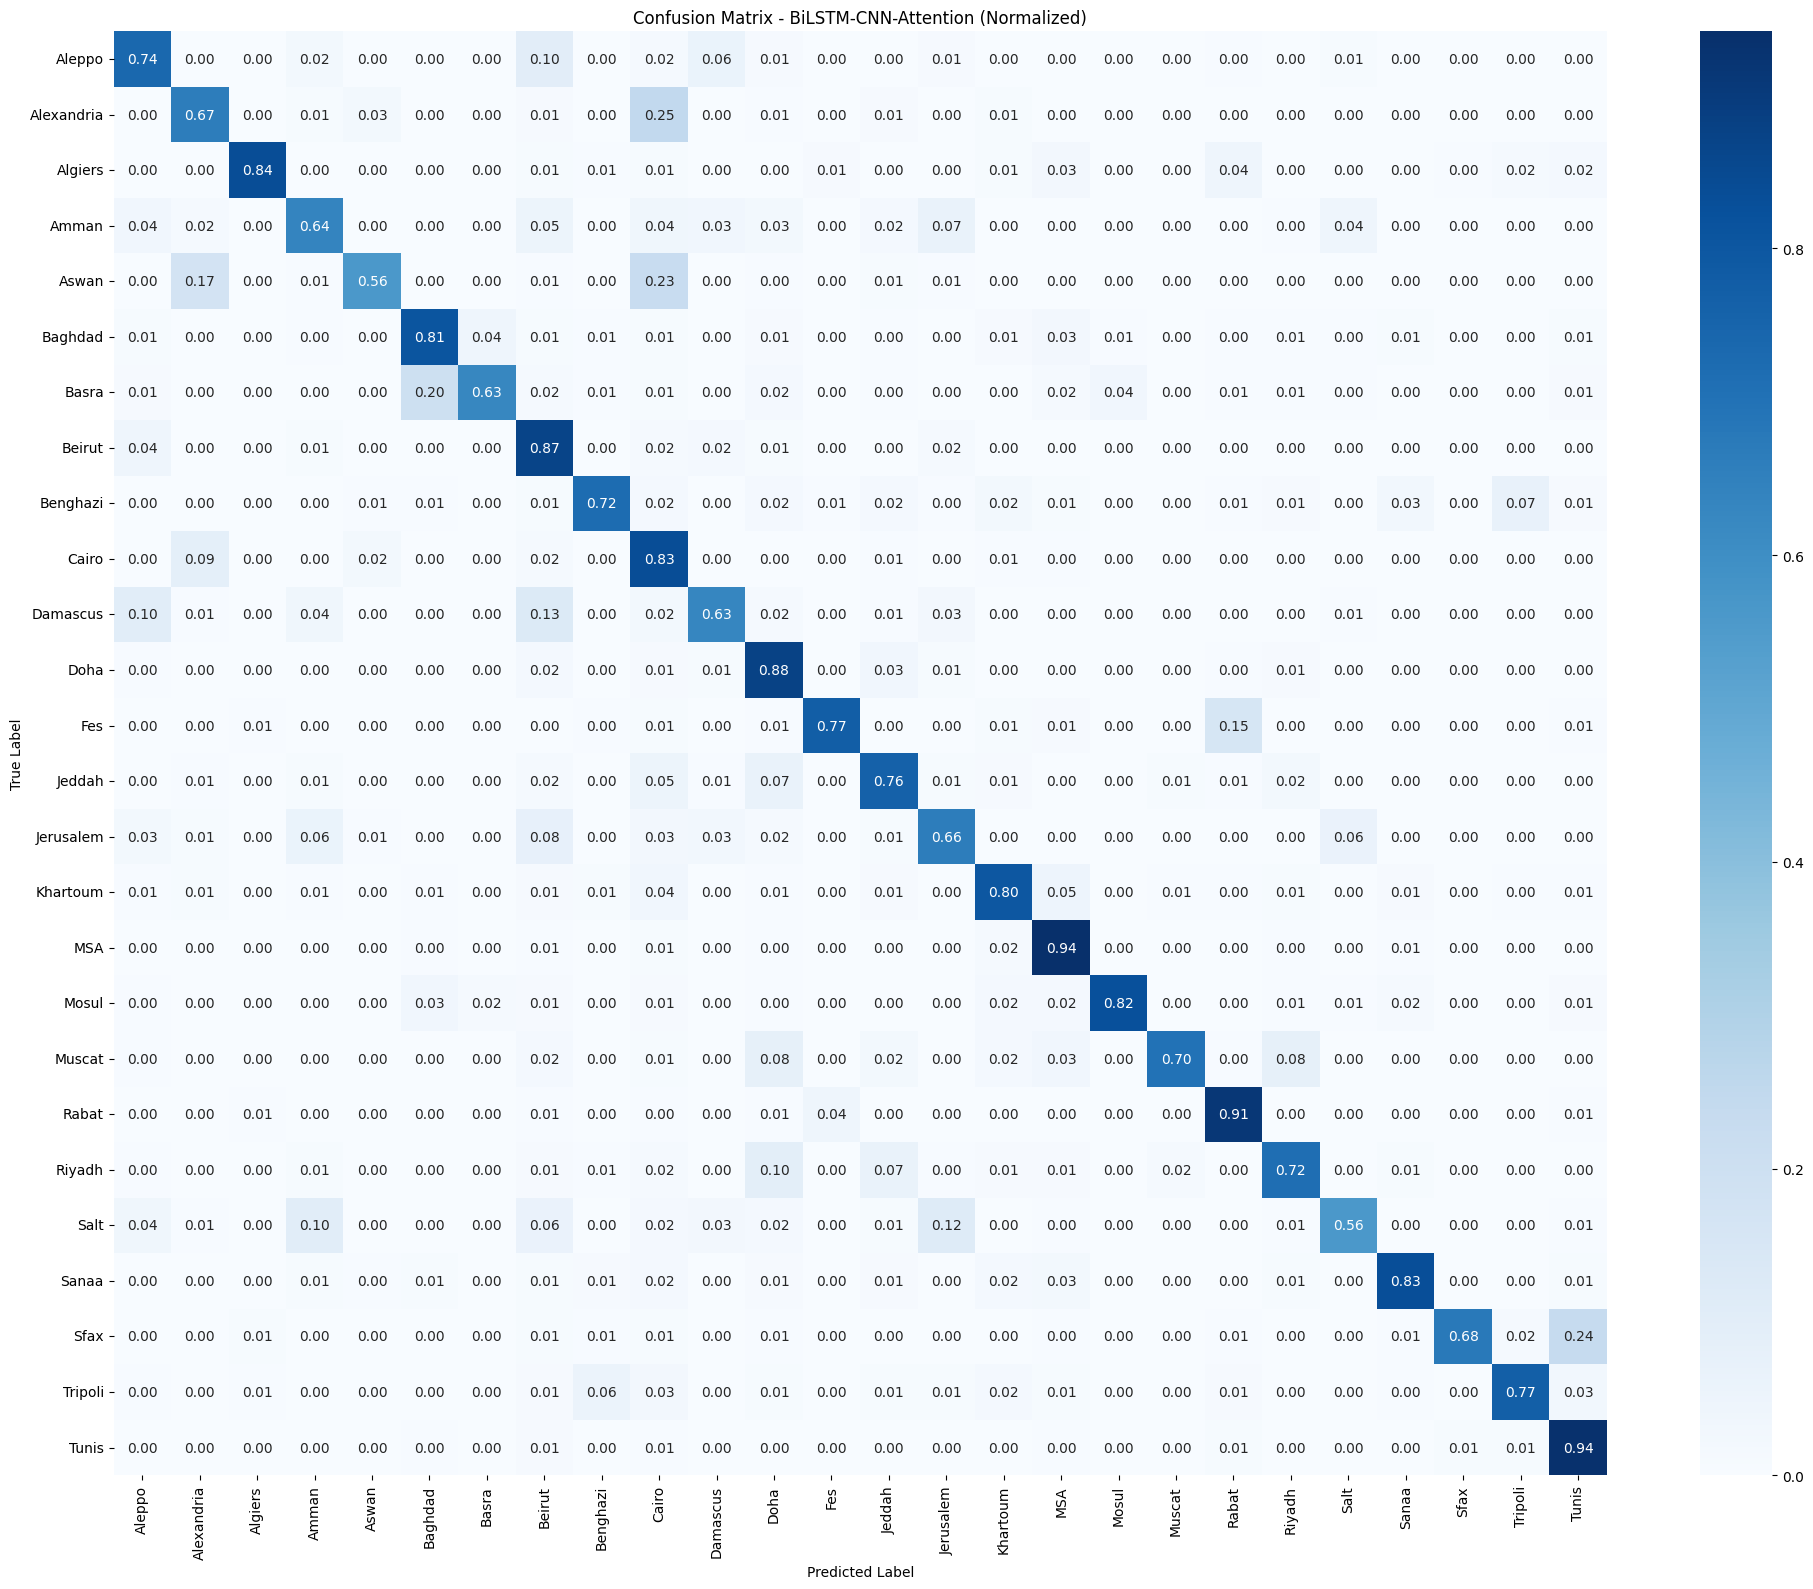

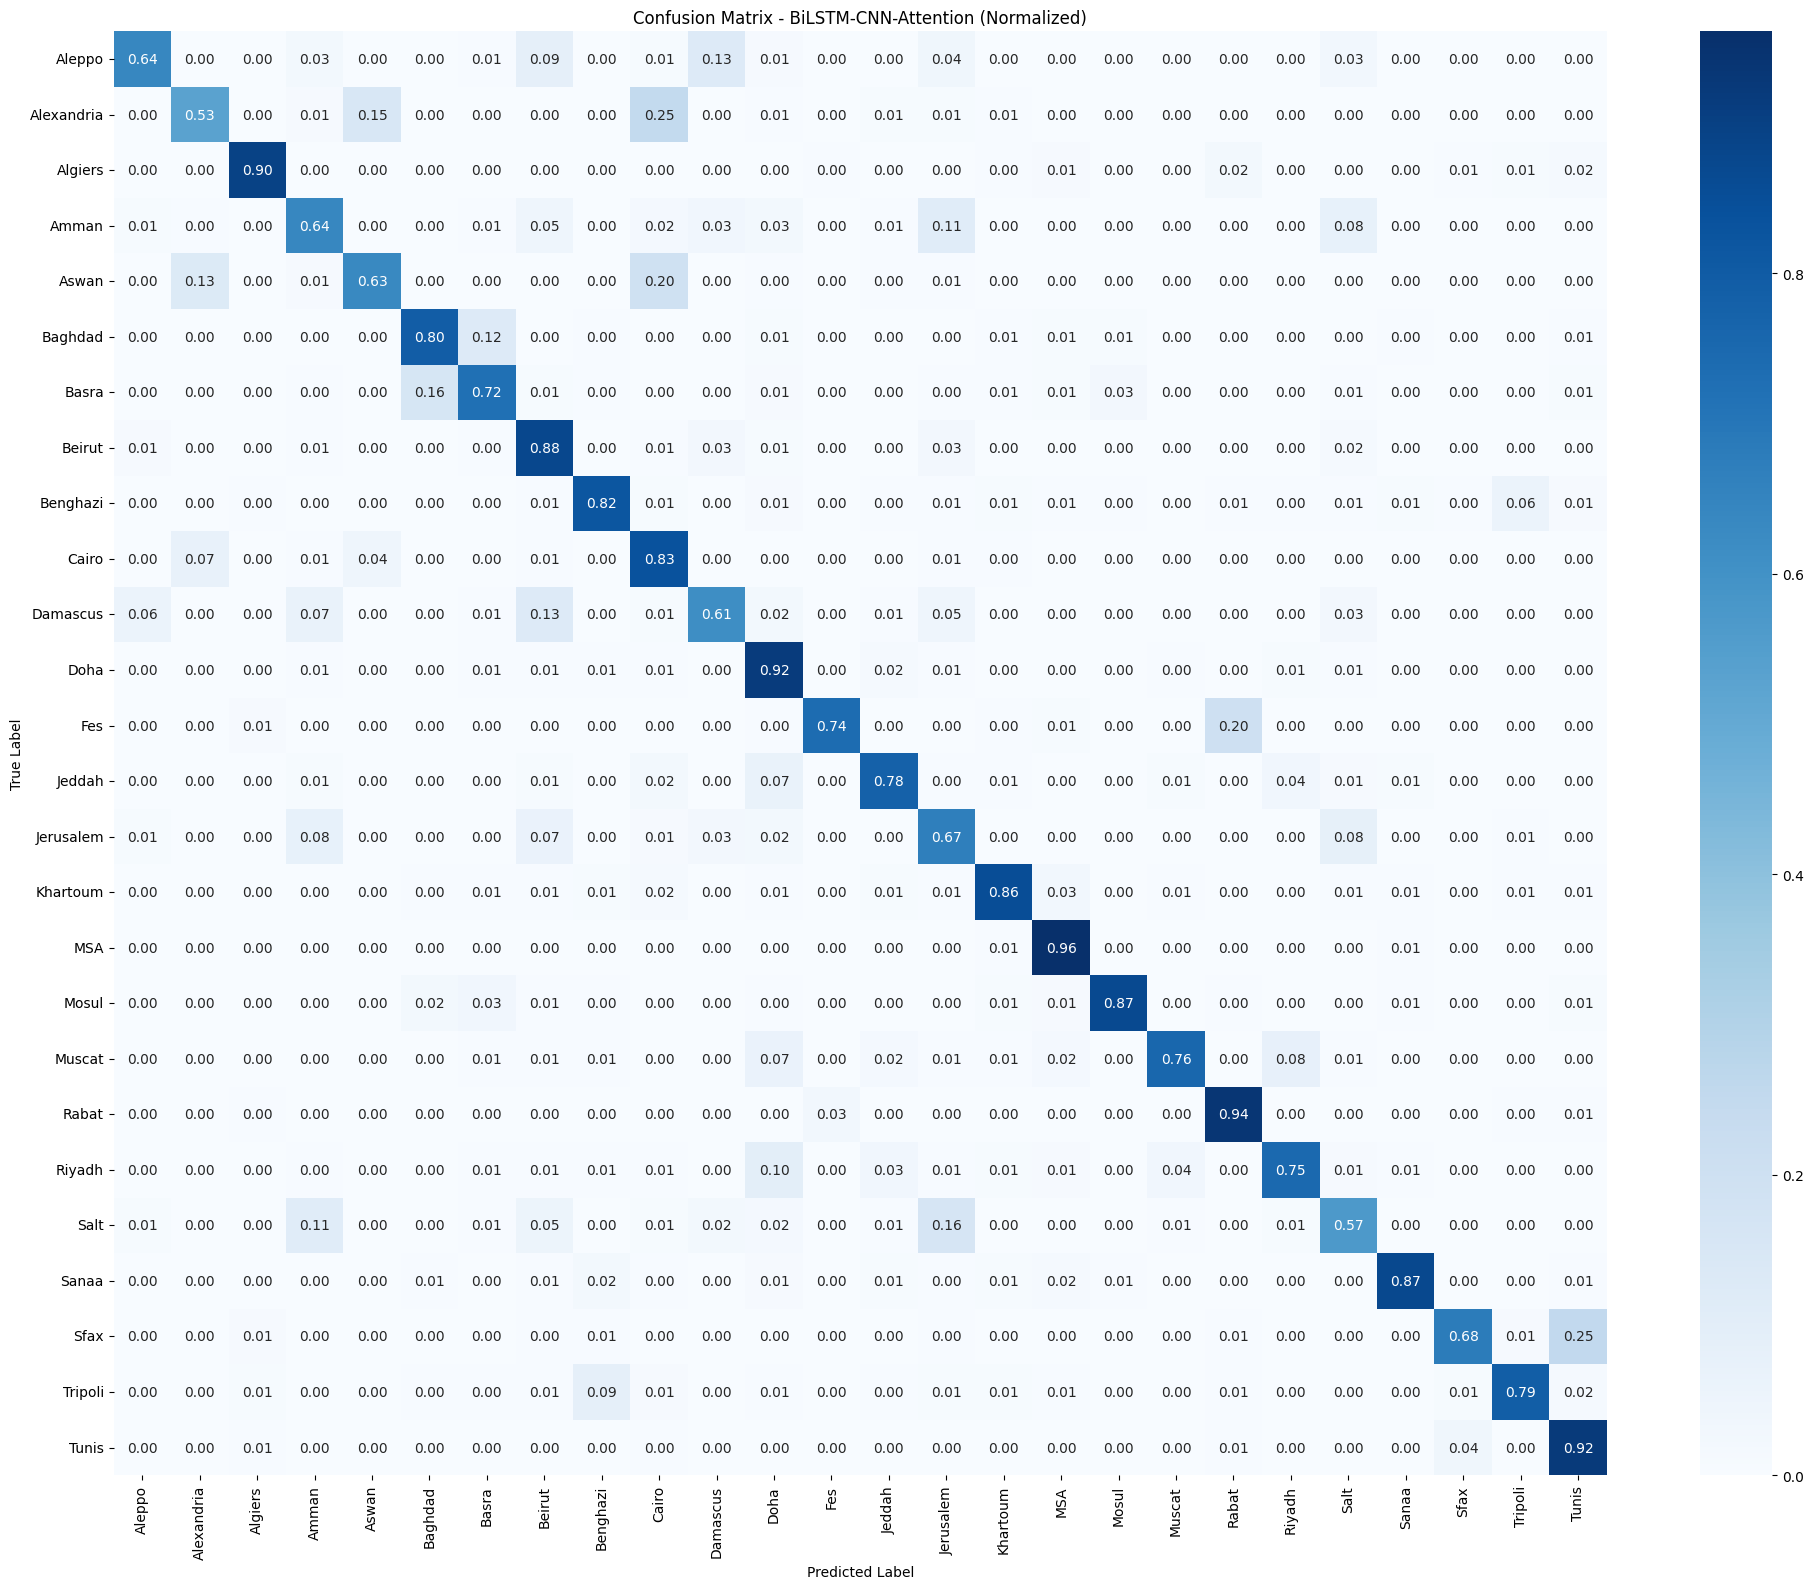

In [29]:
# Plot confusion matrix
def plot_confusion_matrix(results, model_name, normalize=True):
    cm = confusion_matrix(results['true_labels'], results['predictions'])
    
    if normalize:
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_plot = cm_normalized
        fmt = '.2f'
        title_suffix = '(Normalized)'
    else:
        cm_plot = cm
        fmt = 'd'
        title_suffix = ''
    
    plt.figure(figsize=(20, 16))
    sns.heatmap(
        cm_plot, 
        annot=True,
        cmap='Blues', 
        xticklabels=list(dialect_mapping.keys()),
        yticklabels=list(dialect_mapping.keys()),
        fmt=fmt,
    )
    plt.title(f'Confusion Matrix - {model_name} {title_suffix}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}{"_norm" if normalize else ""}.png', dpi=300)
    plt.show()

# Plot normalized confusion matrices
plot_confusion_matrix(bilstm_results, "BiLSTM-CNN-Attention")
if marbert_model is not None:
    plot_confusion_matrix(transformer_results, "BiLSTM-CNN-Attention")


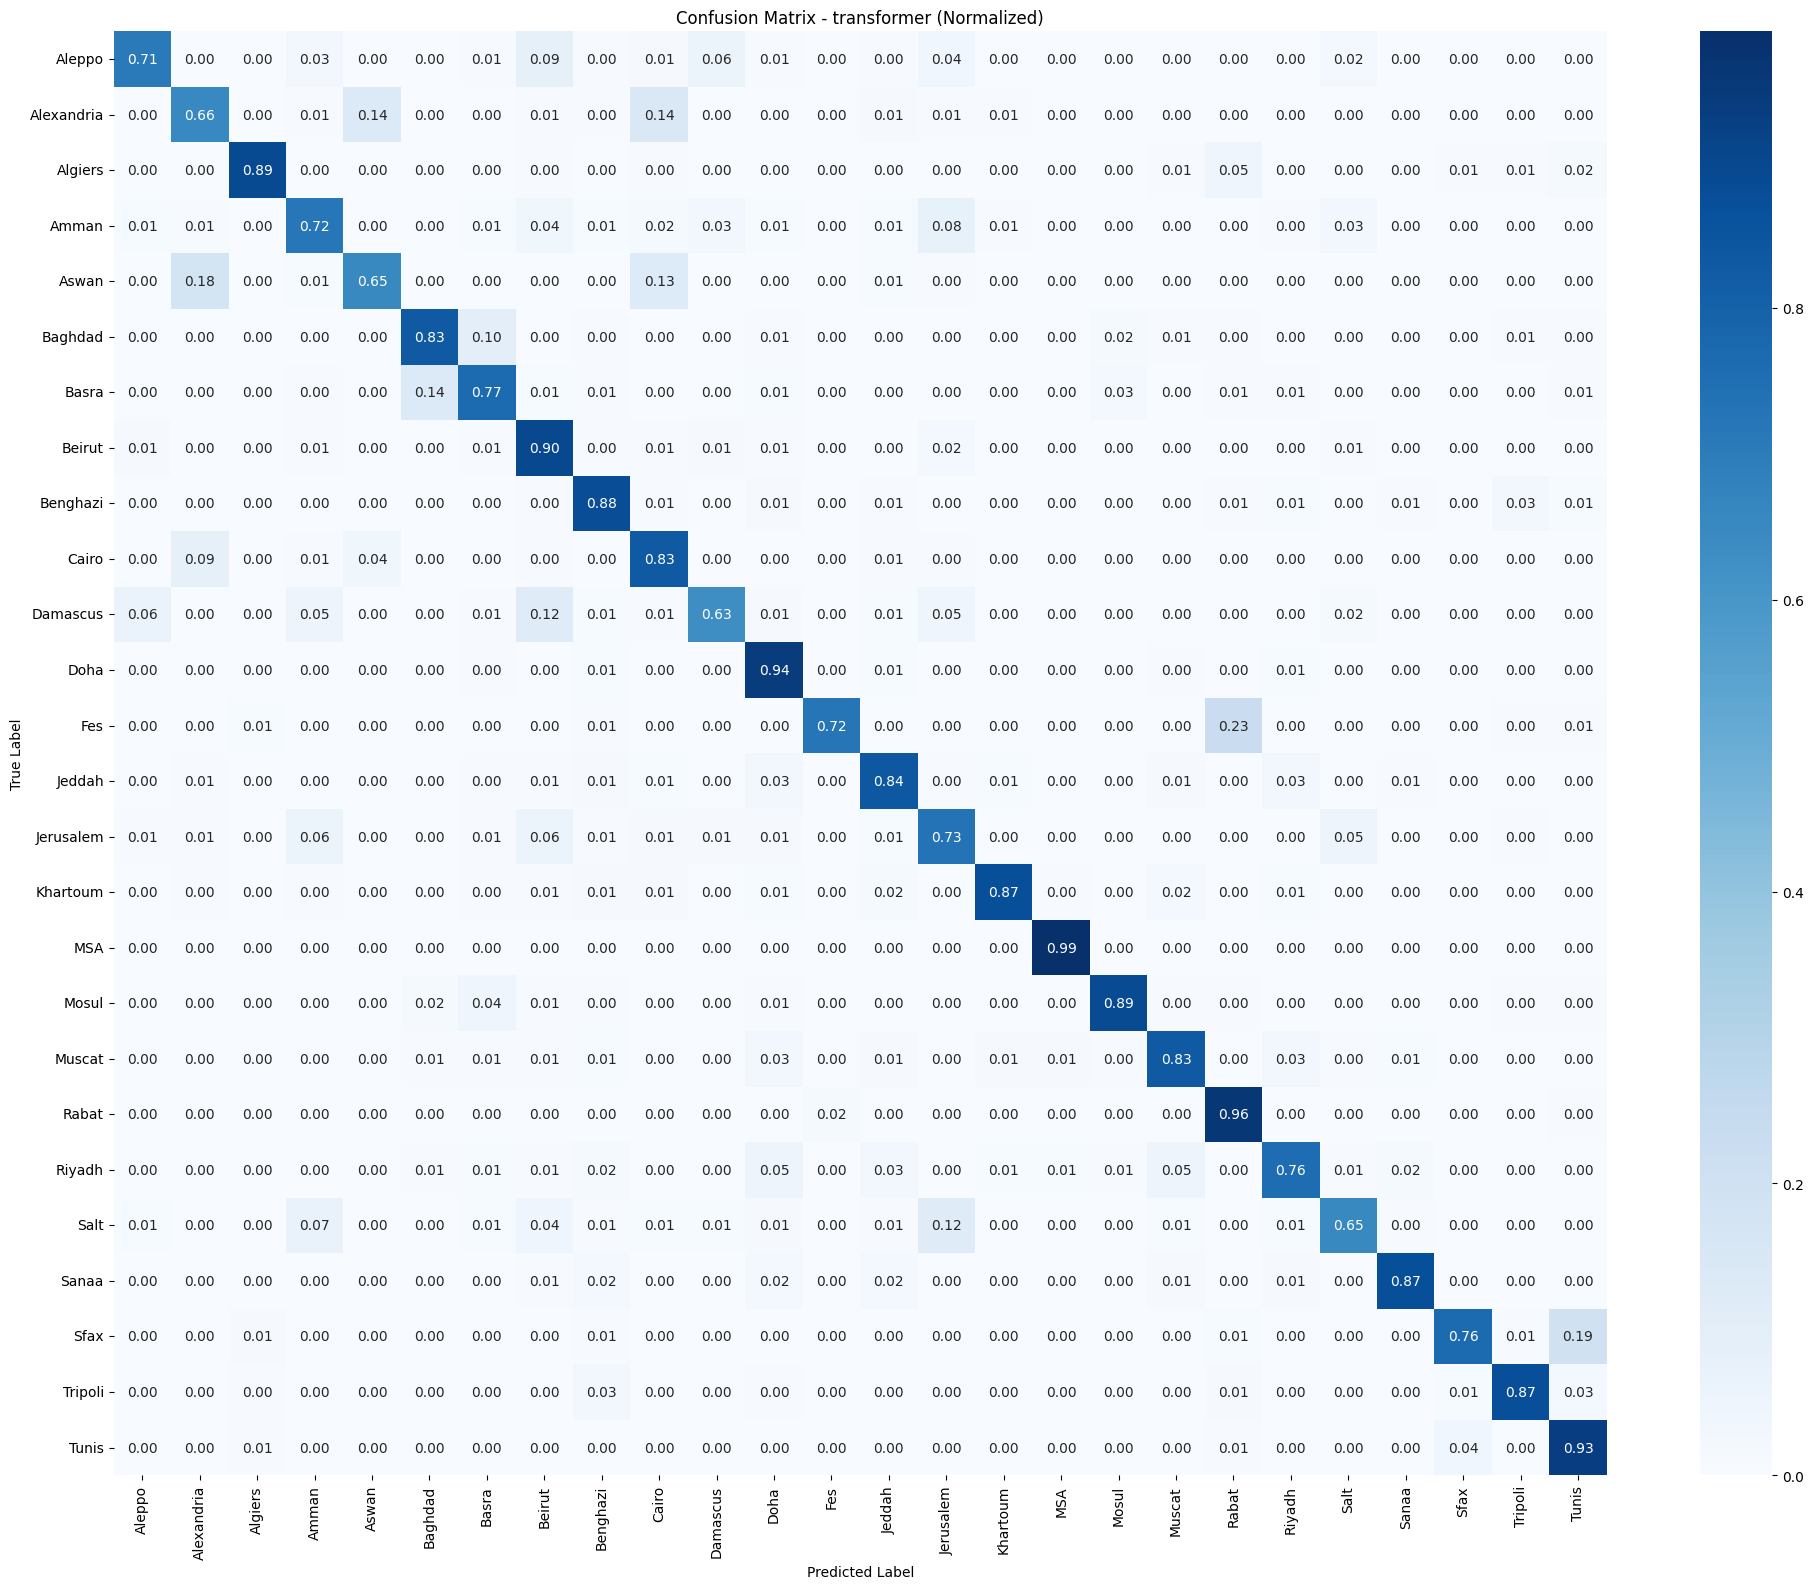

In [39]:
plot_confusion_matrix(transformer_results, "transformer")
